In [1]:
import sys, os

import torch
import torch.nn.functional as F
import pandas as pd

CKPT_PATH = "fox.ckpt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from training.model import Fox

ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
hp   = ckpt["hparams"]

# Infer num_cross_layers from state dict (not stored in hparams)
num_cross_layers = max(
    int(k.split(".")[1]) for k in ckpt["model"] if k.startswith("cross_attn_h2p.")
) + 1

model = Fox(
    hidden_dim            = 256,
    pair_dim              = hp.get("pair_dim", 64),
    num_heads             = 8,
    axial_layers          = hp.get("axial_layers", 2),
    use_opm               = hp.get("use_opm", False),
    use_dist_matrix       = True,
    gradient_checkpointing= False,
    num_cross_layers      = num_cross_layers,
    cls_dim               = hp.get("cls_dim", 512),
    use_flexattention     = False,   # FlexAttention needs CUDA; disabled for local inference
    dropout               = 0.0,
)
model.load_state_dict(ckpt["model"])
model.to(device).eval()
print(f"Model loaded ({num_cross_layers} cross layers, {sum(p.numel() for p in model.parameters()):,} params)")

Model loaded (2 cross layers, 39,581,830 params)


In [2]:
# ── Encoding utilities (mirrors pre_encoder.py) ─────────────────────
import re

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY-"
AA_TO_INDEX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}
UNK_ID, PAD_ID = 21, 22
MAX_SEQ_LEN = 250

def encode_sequence(seq, max_len=MAX_SEQ_LEN):
    enc = [AA_TO_INDEX.get(aa, UNK_ID) for aa in seq[:max_len]]
    enc += [PAD_ID] * (max_len - len(enc))
    return torch.tensor(enc, dtype=torch.long)

def jukes_cantor_dist(msa: torch.Tensor) -> torch.Tensor:
    valid = (msa != PAD_ID)
    valid_pair = valid.unsqueeze(1) & valid.unsqueeze(0)
    n_v = valid_pair.sum(dim=2).clamp(min=1).float()
    mismatch = (msa.unsqueeze(1) != msa.unsqueeze(0)) & valid_pair
    p = mismatch.float().sum(dim=2) / n_v
    p = p.clamp(0.0, 0.74)
    dist = -0.75 * torch.log(1.0 - (4.0 / 3.0) * p)
    dist.fill_diagonal_(0.0)
    return dist

def load_pt(path):
    s = torch.load(path, map_location="cpu", weights_only=False)
    if "host_msa" in s:
        return s["host_msa"], s["para_msa"], s["host_dist"], s["para_dist"], s["mappings"], s.get("labels")
    host_msas = s["host_msas"]
    para_msas = s["parasite_msas"]
    h_idx = {n: i for i, n in enumerate(host_msas)}
    p_idx = {n: i for i, n in enumerate(para_msas)}
    host_tok = torch.stack([encode_sequence(seq) for seq in host_msas.values()])
    para_tok = torch.stack([encode_sequence(seq) for seq in para_msas.values()])
    raw_mappings = s["mappings"]
    if raw_mappings and isinstance(raw_mappings[0], (tuple, list)) and isinstance(raw_mappings[0][0], str):
        mappings = [(h_idx[h], p_idx[p]) for p, h in raw_mappings if p in p_idx and h in h_idx]
    else:
        mappings = raw_mappings
    _hd = s.get("host_dist")
    _pd = s.get("para_dist")
    host_dist = _hd if _hd is not None else jukes_cantor_dist(host_tok)
    para_dist = _pd if _pd is not None else jukes_cantor_dist(para_tok)
    labels = s.get("event_frequencies") if s.get("event_frequencies") is not None else s.get("labels")
    return host_tok, para_tok, host_dist, para_dist, mappings, labels

_FREQ_KEYS = {"Speciation_freq": "Speciation", "HGT_freq": "HGT",
              "Loss_freq": "Loss", "Duplication_freq": "Duplication", "Sim_time": "Sim_time"}

def parse_tgl(path):
    result = dict(host_tree=None, para_tree=None,
                  host_msa={}, para_msa={},
                  distribution=[], event_freqs={})
    section, in_aln = None, False
    with open(path) as f:
        for line in f:
            s = line.strip()
            if s.startswith("BEGIN HOST;"):
                section, in_aln = "HOST", False; continue
            elif s.startswith("BEGIN PARASITE;"):
                section, in_aln = "PARA", False; continue
            elif s.startswith("BEGIN DISTRIBUTION;"):
                section = "DIST"; continue
            elif s in ("ENDBLOCK;", "END;"):
                section, in_aln = None, False; continue
            if section in ("HOST", "PARA"):
                import re as _re
                m = _re.match(r"TREE \* \S+ = (.+)", s)
                if m:
                    key = "host_tree" if section == "HOST" else "para_tree"
                    result[key] = m.group(1).rstrip(";"); continue
                if s.startswith("ALIGNMENT"):
                    in_aln = True; continue
                if in_aln and s == "'":
                    in_aln = False; continue
                if in_aln:
                    parts = s.split()
                    if len(parts) == 2:
                        d = result["host_msa"] if section == "HOST" else result["para_msa"]
                        d[parts[0]] = parts[1]
            elif section == "DIST":
                if ":" in s:
                    p, h = [x.strip() for x in s.split(":", 1)]
                    result["distribution"].append((p, h))
            else:
                for raw_key, std_key in _FREQ_KEYS.items():
                    if s.startswith(raw_key + ":"):
                        try:
                            result["event_freqs"][std_key] = float(s.split(":", 1)[1].strip())
                        except ValueError:
                            pass
    return result

def load_tgl(path):
    d = parse_tgl(path)
    host_msas, para_msas = d["host_msa"], d["para_msa"]
    h_idx = {n: i for i, n in enumerate(host_msas)}
    p_idx = {n: i for i, n in enumerate(para_msas)}
    host_tok = torch.stack([encode_sequence(seq) for seq in host_msas.values()])
    para_tok = torch.stack([encode_sequence(seq) for seq in para_msas.values()])
    mappings = [(h_idx[h], p_idx[p])
                for p, h in d["distribution"] if p in p_idx and h in h_idx]
    labels = d["event_freqs"] or None
    return host_tok, para_tok, jukes_cantor_dist(host_tok), jukes_cantor_dist(para_tok), mappings, labels

print("Encoding utilities ready.")

Encoding utilities ready.


In [3]:
# ── Inference on a list of files ─────────────────────────────────────────────
EVENT_NAMES = ["Speciation", "HGT", "Loss", "Duplication"]
EVENT_LABELS = {"Speciation": "Cospeciation", "HGT": "Host switch", "Loss": "Loss", "Duplication": "Duplication"}
def disp(e): return EVENT_LABELS.get(e, e)  # plot label only; data keys stay "HGT"

def predict(paths):
    """
    paths    : list of .pt or .tgl file paths
    Returns  : pd.DataFrame with columns file, pred_*, [true_* if labels present]
    """
    rows = []
    with torch.no_grad():
        for path in paths:
            ext = os.path.splitext(path)[1].lower()
            if ext == ".pt":
                host_msa, para_msa, host_dist, para_dist, mappings, labels = load_pt(path)
            elif ext == ".tgl":
                host_msa, para_msa, host_dist, para_dist, mappings, labels = load_tgl(path)
            else:
                raise ValueError(f"Unknown extension {ext!r} — expected .pt or .tgl")

            out = model(
                host_msa.unsqueeze(0).to(device),
                para_msa.unsqueeze(0).to(device),
                [mappings],
                host_dist=host_dist.unsqueeze(0).to(device),
                para_dist=para_dist.unsqueeze(0).to(device),
            )  # [1, 4]

            pred = out.squeeze(0).cpu().tolist()
            row  = {"file": os.path.basename(path)}
            row.update({f"pred_{n}": v for n, v in zip(EVENT_NAMES, pred)})

            if isinstance(labels, dict):
                row.update({f"true_{n}": labels.get(n, float("nan")) for n in EVENT_NAMES})

            rows.append(row)

    return pd.DataFrame(rows)

print("predict() ready.")

predict() ready.


In [4]:
DATA_DIR = "test_data/fox_data"   

import glob
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.pt")))

print(f"Found {len(files)} files")
df = predict(files)
df['speciation_diff'] = df['pred_Speciation'] -  df['true_Speciation']
df['HGT_diff'] = df['pred_HGT'] - df['true_HGT']
df['Loss_diff'] = df['pred_Loss'] - df['true_Loss']
df['Duplication_diff'] = df['pred_Duplication'] - df['true_Duplication']
print(df)

Found 100 files


KeyboardInterrupt: 

In [ ]:
from scipy import stats
from sklearn.metrics import r2_score
import numpy as np

rows_metrics = []
for event in EVENT_NAMES:
    true = df[f"true_{event}"].values
    pred = df[f"pred_{event}"].values
    diff = pred - true
    mae  = np.abs(diff).mean()
    rmse = np.sqrt((diff**2).mean())
    r2   = r2_score(true, pred)
    bias = diff.mean()
    rows_metrics.append({
        "Event": event,
        "MAE": mae,
        'MRE': mae / np.mean(true) if np.mean(true) > 0 else 1e-6,
        "RMSE": rmse,
        "R²": r2,
        "Bias": bias,
    })

metrics_df = pd.DataFrame(rows_metrics).set_index("Event")
print(metrics_df.round(4))


                MAE     MRE    RMSE      R²    Bias
Event                                              
Speciation   0.0241  0.0414  0.0298  0.9105  0.0072
HGT          0.0250  0.2089  0.0314  0.6115 -0.0101
Loss         0.0157  0.1250  0.0220  0.8309 -0.0050
Duplication  0.0232  0.1346  0.0295  0.5620  0.0079


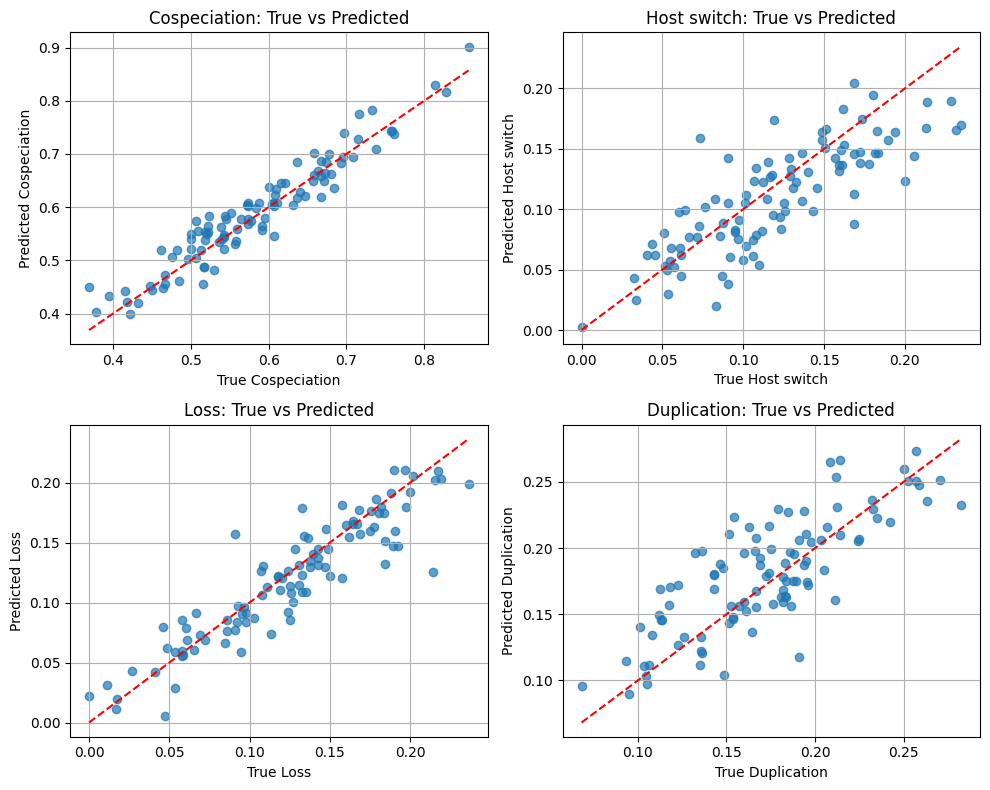

In [ ]:
# plot true vs predicted
import matplotlib.pyplot as plt
import math

n = len(EVENT_NAMES)
cols = math.ceil(math.sqrt(n))
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, event in zip(axes, EVENT_NAMES):
    true = df[f"true_{event}"]
    pred = df[f"pred_{event}"]
    ax.scatter(true, pred, alpha=0.7)
    ax.plot([true.min(), true.max()], [true.min(), true.max()], 'r--')
    ax.set_xlabel(f"True {disp(event)}")
    ax.set_ylabel(f"Predicted {disp(event)}")
    ax.set_title(f"{disp(event)}: True vs Predicted")
    ax.grid(True)

# hide unused axes
for ax in axes[n:]:
    ax.set_visible(False)

fig.tight_layout()
plt.savefig("test_data/fox_predictions.png", dpi=120, bbox_inches="tight")
plt.show()

## AmoCoala comparison on simulated test data



In [ ]:
import os, subprocess, glob
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import time, threading

TGL_DIR    = "test_data/Datasets"
SIM_AC_DIR = "test_data/amocoala_data"
os.makedirs(SIM_AC_DIR, exist_ok=True)

AMOCOALA_JAR = os.environ.get("AMOCOALA_JAR", "/Users/gabriele/AmoCoala-main/AmoCoala.jar")
TEST_N_SIM   = None  # set to int to limit, e.g. 10
N_ROUNDS     = 1
T_VECTOR     = ",".join(["0.1"] * N_ROUNDS)  # -t needs one threshold per round

_STRIP_BL  = re.compile(r":[0-9eE+\-.]*[0-9]")
_STRIP_INT = re.compile(r"\)[A-Za-z0-9_]+")

def _parse_newick_subtrees(nwk):
    nwk = _STRIP_BL.sub("", nwk.strip().rstrip(";"))
    subtree_leaves = {}
    def parse(s, pos):
        if s[pos] == "(":
            pos += 1
            all_leaves = []
            while pos < len(s) and s[pos] != ")":
                child_leaves, pos, _ = parse(s, pos)
                all_leaves.extend(child_leaves)
                if pos < len(s) and s[pos] == ",":
                    pos += 1
            pos += 1
            name_start = pos
            while pos < len(s) and s[pos] not in ",)(":
                pos += 1
            node_name = s[name_start:pos].strip()
            if node_name:
                subtree_leaves[node_name] = set(all_leaves)
            return all_leaves, pos, node_name
        else:
            name_start = pos
            while pos < len(s) and s[pos] not in ",)":
                pos += 1
            leaf_name = s[name_start:pos].strip()
            if leaf_name:
                subtree_leaves[leaf_name] = {leaf_name}
            return [leaf_name], pos, leaf_name
    parse(nwk, 0)
    return subtree_leaves

def _collapse_unary(nwk):
    # AmoCoala's addVerticalSpread only handles binary internal nodes (Tree.java:1018).
    # Unary internals -> entries missing from mapVerticalSpreadAssociations -> NPE at line 1125.
    nwk = nwk.strip().rstrip(";")
    pos = [0]
    def parse():
        if pos[0] < len(nwk) and nwk[pos[0]] == "(":
            pos[0] += 1
            ch = [parse()]
            while pos[0] < len(nwk) and nwk[pos[0]] == ",":
                pos[0] += 1; ch.append(parse())
            pos[0] += 1  # )
            ns = pos[0]
            while pos[0] < len(nwk) and nwk[pos[0]] not in ",()":
                pos[0] += 1
            return (nwk[ns:pos[0]], ch)
        ns = pos[0]
        while pos[0] < len(nwk) and nwk[pos[0]] not in ",()":
            pos[0] += 1
        return (nwk[ns:pos[0]], None)
    def simplify(node):
        label, ch = node
        if ch is None: return node
        new_ch = [simplify(c) for c in ch]
        if len(new_ch) == 1: return new_ch[0]
        return (label, new_ch)
    def ser(node):
        label, ch = node
        if ch is None: return label
        return "(" + ",".join(ser(c) for c in ch) + ")" + label
    return ser(simplify(parse()))

def _expand_dist(distribution, host_nwk):
    st = _parse_newick_subtrees(host_nwk)
    all_leaves = {n for n, v in st.items() if v == {n}}
    expanded, seen = [], set()
    for p, h in distribution:
        targets = [h] if h in all_leaves else sorted(st.get(h, []))
        for t in targets:
            if (p, t) not in seen:
                expanded.append((p, t))
                seen.add((p, t))
    return expanded

def run_amocoala_on_tgl(tgl_path, out_dir, n_rounds=N_ROUNDS, t_vector=T_VECTOR):
    os.makedirs(out_dir, exist_ok=True)
    stem       = os.path.splitext(os.path.basename(tgl_path))[0]
    nex_path   = os.path.join(out_dir, f"{stem}.nex")
    result_csv = f"{nex_path}.accep.round_{n_rounds}.csv"
    if os.path.exists(result_csv):
        return result_csv, None
    d = parse_tgl(tgl_path)
    if d["host_tree"] is None or d["para_tree"] is None:
        return None, "Could not parse trees"
    expanded_dist = _expand_dist(d["distribution"], d["host_tree"])
    host_nwk = _collapse_unary(_STRIP_INT.sub(")", _STRIP_BL.sub("", d["host_tree"])))
    para_nwk = _collapse_unary(_STRIP_INT.sub(")", _STRIP_BL.sub("", d["para_tree"])))
    host_leaves = {n for n, v in _parse_newick_subtrees(host_nwk).items() if v == {n}}
    para_leaves = {n for n, v in _parse_newick_subtrees(para_nwk).items() if v == {n}}
    expanded_dist = [(p, h) for p, h in expanded_dist if p in para_leaves and h in host_leaves]
    if len(expanded_dist) < 3:
        return None, f"Too few valid leaf mappings: {len(expanded_dist)}"
    map_strs = [f"{p} : {h}" for p, h in expanded_dist]
    nexus = (
        "#NEXUS\n"
        f"BEGIN HOST;\n\tTREE HOST = {host_nwk};\nENDBLOCK;\n"
        f"BEGIN PARASITE;\n\tTREE PARASITE = {para_nwk};\nENDBLOCK;\n"
        "BEGIN DISTRIBUTION;\n\tRANGE\n\t\t"
        + ", ".join(map_strs)
        + ";\nENDBLOCK;\n"
    )
    with open(nex_path, "w") as f:
        f.write(nexus)
    r = subprocess.run(
        f"java -jar {AMOCOALA_JAR} -input {nex_path} -N 1000 -M 100 -R {n_rounds} -t {t_vector}",
        shell=True, capture_output=True, text=True, timeout=6000)
    if os.path.exists(result_csv):
        return result_csv, None
    return None, (r.stderr or r.stdout)[:300]


all_tgls = sorted(glob.glob(os.path.join(TGL_DIR, "*.tgl")))
if TEST_N_SIM and TEST_N_SIM < len(all_tgls):
    idx = [round(i * (len(all_tgls) - 1) / (TEST_N_SIM - 1)) for i in range(TEST_N_SIM)]
    run_tgls = [all_tgls[i] for i in idx]
else:
    run_tgls = all_tgls

print(f"Running AmoCoala on {len(run_tgls)} datasets ({N_ROUNDS} rounds, true trees, no IQ-TREE):")

def _run_one(args):
    tgl_path, out_dir = args
    t0 = time.time()
    print(f"[{time.strftime('%H:%M:%S')}] START {os.path.basename(tgl_path)}", flush=True)
    csv, err = run_amocoala_on_tgl(tgl_path, out_dir)
    elapsed = time.time() - t0
    status = 'OK' if csv else 'FAIL'
    print(f"[{time.strftime('%H:%M:%S')}] {status} {os.path.basename(tgl_path)} ({elapsed:.0f}s)", flush=True)
    return tgl_path, csv, err

jobs = [(p, os.path.join(SIM_AC_DIR, os.path.splitext(os.path.basename(p))[0])) for p in run_tgls]
failed_sim = []
with ThreadPoolExecutor(max_workers=min(len(run_tgls), os.cpu_count())) as ex:
    futures = {ex.submit(_run_one, j): j for j in jobs}
    for fut in tqdm(as_completed(futures), total=len(jobs)):
        tgl_path, csv, err = fut.result()
        if csv is None:
            failed_sim.append((os.path.basename(tgl_path), err))

n_done = len(run_tgls) - len(failed_sim)
print(f"\nDone: {n_done} / {len(run_tgls)}")
if failed_sim:
    print("Failed:", failed_sim)


Running AmoCoala on 40 datasets (1 rounds, true trees, no IQ-TREE):
[09:33:05] START Dataset11.tgl
[09:33:05] START Dataset12.tgl
[09:33:05] START Dataset16.tgl[09:33:05] START Dataset17.tgl

[09:33:05] START Dataset18.tgl
[09:33:05] OK Dataset11.tgl (0s)
[09:33:05] OK Dataset12.tgl (0s)
[09:33:05] START Dataset26.tgl
[09:33:05] OK Dataset16.tgl (0s)
[09:33:05] OK Dataset17.tgl (0s)
[09:33:05] START Dataset27.tgl
[09:33:05] OK Dataset18.tgl (0s)
[09:33:05] START Dataset28.tgl
[09:33:05] START Dataset30.tgl[09:33:05] START Dataset31.tgl
[09:33:05] START Dataset32.tgl
[09:33:05] START Dataset33.tgl
[09:33:05] START Dataset35.tgl

[09:33:05] START Dataset36.tgl
[09:33:05] OK Dataset27.tgl (0s)
[09:33:05] OK Dataset26.tgl (0s)
[09:33:05] START Dataset37.tgl
[09:33:05] START Dataset38.tgl
[09:33:05] OK Dataset28.tgl (0s)
[09:33:05] START Dataset39.tgl
[09:33:05] OK Dataset31.tgl (0s)
[09:33:05] START Dataset40.tgl
[09:33:05] OK Dataset32.tgl (0s)[09:33:05] OK Dataset35.tgl (0s)
[09:33:05] S

  0%|          | 0/40 [00:00<?, ?it/s]

[09:33:05] OK Dataset99.tgl (0s)


100%|██████████| 40/40 [00:00<00:00, 72723.09it/s]


Done: 40 / 40


8 hours and 40 minutes -> 41 datasets done by amocoala -> It stopped since it was taking too much time to do some datasets 

In [ ]:
# Reuse predictions from df (cell In[4]) — already ran model on all .pt in DATA_DIR.
# Map each .tgl -> matching .pt by event_frequencies tuple, then filter df.
PT_DIR = DATA_DIR  # same folder used by In[4]

_FREQ_FIELDS = ["Speciation", "HGT", "Loss", "Duplication", "Sim_time"]
def _label_key(freqs):
    return tuple(round(float(freqs.get(k, 0.0)), 5) for k in _FREQ_FIELDS)

pt_index = {}
for p in sorted(glob.glob(os.path.join(PT_DIR, "*.pt"))):
    s = torch.load(p, map_location="cpu", weights_only=False)
    freqs = s.get("event_frequencies") or s.get("labels")
    if isinstance(freqs, dict):
        pt_index[_label_key(freqs)] = os.path.basename(p)

run_tgls = all_tgls
pt_to_tgl_name, missing = {}, []
for tgl in run_tgls:
    freqs = parse_tgl(tgl)["event_freqs"]
    pt_name = pt_index.get(_label_key(freqs))
    if pt_name is None:
        missing.append(os.path.basename(tgl))
    else:
        pt_to_tgl_name[pt_name] = os.path.basename(tgl)
if missing:
    print(f"WARNING: no .pt match for {len(missing)} tgls: {missing[:5]}...")

df_tgl_pred = df[df["file"].isin(pt_to_tgl_name)].copy()
df_tgl_pred["file"] = df_tgl_pred["file"].map(pt_to_tgl_name)
print("reused", len(df_tgl_pred), "predictions from df (no re-inference)")

reused 40 predictions from df (no re-inference)


In [ ]:
# ── Parse AmoCoala results + 3-way comparison ─────────────────────
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import r2_score

SIM_AC_DIR = "test_data/amocoala_data"
def _parse_ac_csv(csv_path):
    rows = []
    with open(csv_path) as f:
        for line in f:
            vals = [float(x) for x in line.strip().split("\t") if x.strip()]
            if len(vals) >= 4:
                rows.append(vals)
    if not rows:
        return None
    arr = np.array(rows)
    cospec, dup, hsw, loss = arr[:,0].mean(), arr[:,1].mean(), arr[:,2].mean(), arr[:,3].mean()
    total = cospec + dup + hsw + loss or 1.0
    return {"Speciation": cospec/total, "Duplication": dup/total,
            "HGT": hsw/total, "Loss": loss/total}

ac_rows = []
for tgl_path in run_tgls:
    stem = os.path.splitext(os.path.basename(tgl_path))[0]
    csv  = os.path.join(SIM_AC_DIR, stem, f"{stem}.nex.accep.round_1.csv")
    if not os.path.exists(csv):
        continue
    freqs = _parse_ac_csv(csv)
    if freqs is None:
        continue
    true = parse_tgl(tgl_path)["event_freqs"]
    row  = {"file": f"{stem}.tgl"}
    row.update({f"ac_{e}":   freqs.get(e, float("nan")) for e in EVENT_NAMES})
    row.update({f"true_{e}": true.get(e,  float("nan")) for e in EVENT_NAMES})
    ac_rows.append(row)

df_sac  = pd.DataFrame(ac_rows)
df_cmp3 = df_sac.merge(
    df_tgl_pred[["file"] + [f"pred_{e}" for e in EVENT_NAMES]],
    on="file", how="inner")
print(f"Matched: {len(df_cmp3)} samples")
print(df_cmp3[["file"]
              + [f"true_{e}" for e in EVENT_NAMES]
              + [f"ac_{e}"   for e in EVENT_NAMES]
              + [f"pred_{e}" for e in EVENT_NAMES]].to_string(index=False))

rows_ac, rows_mdl = [], []
for event in EVENT_NAMES:
    t = df_cmp3[f"true_{event}"].values
    a = df_cmp3[f"ac_{event}"].values
    p = df_cmp3[f"pred_{event}"].values
    rows_ac.append({"Event": event,
        "MAE":  np.abs(a-t).mean(), 'MRE': np.abs(a-t).mean() / np.mean(t) if np.mean(t) > 0 else 1e-6,
        'RMSE': np.sqrt(((a-t)**2).mean()),
        "R2":   r2_score(t, a),     "Pearson r": stats.pearsonr(t, a)[0]})
    rows_mdl.append({"Event": event,
        "MAE":  np.abs(p-t).mean(), 'MRE': np.abs(p-t).mean() / np.mean(t) if np.mean(t) > 0 else 1e-6,
        'RMSE': np.sqrt(((p-t)**2).mean()),
        "R2":   r2_score(t, p),     "Pearson r": stats.pearsonr(t, p)[0]})

df_mtr_ac  = pd.DataFrame(rows_ac).set_index("Event")
df_mtr_mdl = pd.DataFrame(rows_mdl).set_index("Event")
print("\n=== AmoCoala vs truth ===")
print(df_mtr_ac.round(4))
print("\n=== Model vs truth (same subset) ===")
print(df_mtr_mdl.round(4))

Matched: 40 samples
         file  true_Speciation  true_HGT  true_Loss  true_Duplication  ac_Speciation   ac_HGT  ac_Loss  ac_Duplication  pred_Speciation  pred_HGT  pred_Loss  pred_Duplication
Dataset11.tgl           0.8276    0.0517     0.0172            0.1034       0.484580 0.186775 0.232599        0.096047         0.816071  0.052846   0.019787          0.111295
Dataset12.tgl           0.6667    0.1014     0.0580            0.1739       0.522067 0.180962 0.215325        0.081646         0.618622  0.105549   0.059433          0.216396
Dataset16.tgl           0.7568    0.1081     0.0270            0.1081       0.514384 0.249079 0.171211        0.065327         0.743476  0.079055   0.043344          0.134125
Dataset17.tgl           0.5909    0.1591     0.1364            0.1136       0.483634 0.199736 0.219011        0.097618         0.563992  0.136429   0.154035          0.145543
Dataset18.tgl           0.5591    0.1613     0.0860            0.1935       0.513734 0.180937 0.196981   

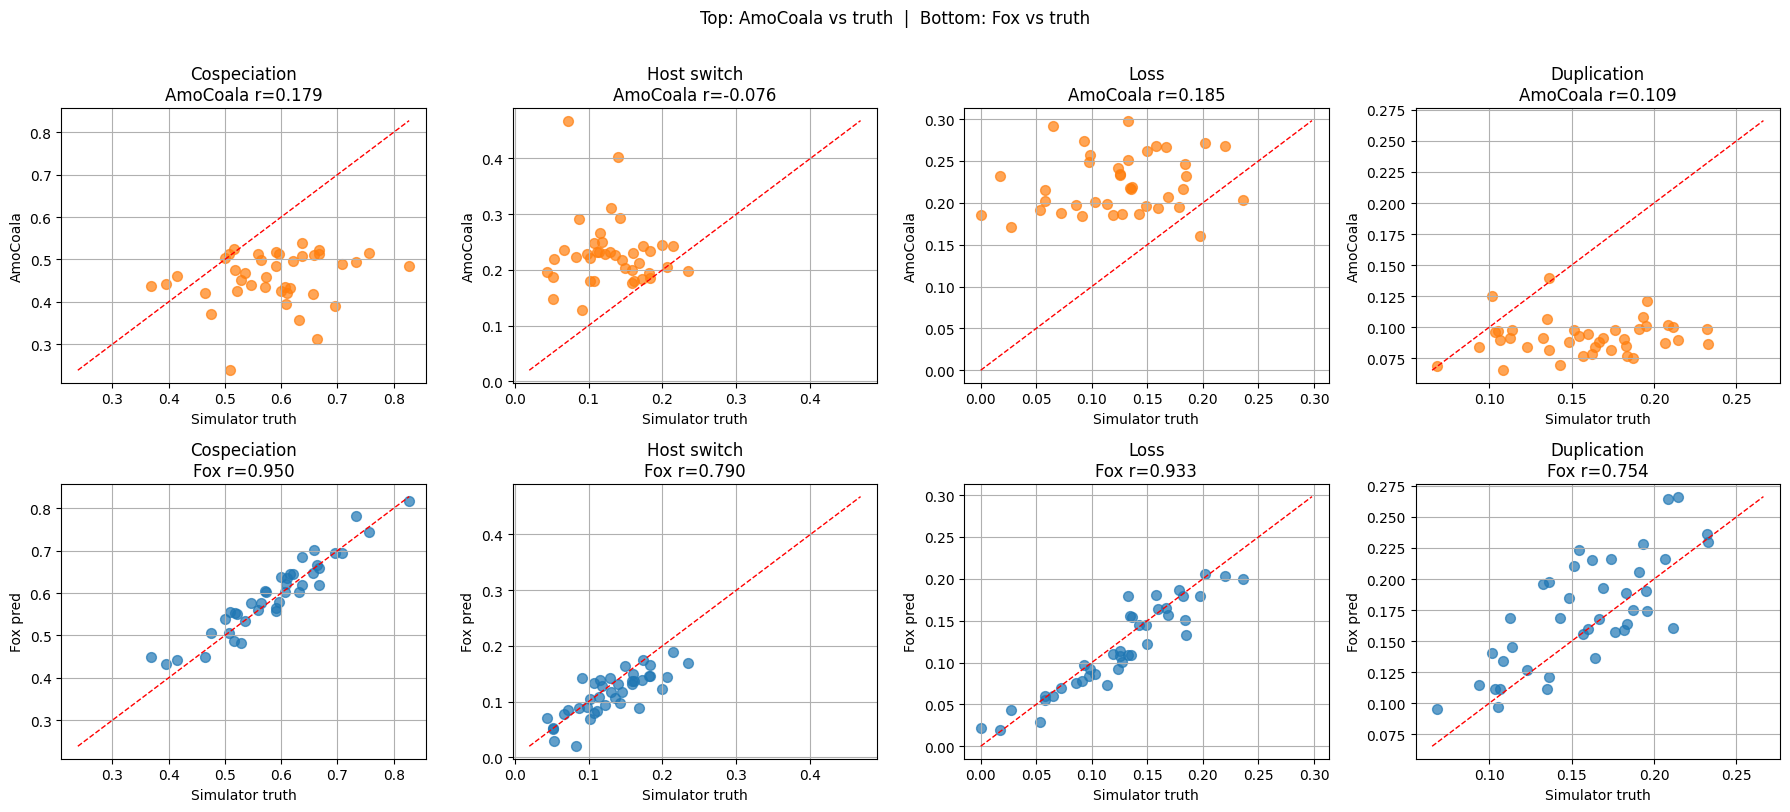

In [ ]:
# ── 3-way scatter: truth vs AmoCoala vs model ────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col, event in enumerate(EVENT_NAMES):
    t = df_cmp3[f'true_{event}'].values
    a = df_cmp3[f'ac_{event}'].values
    p = df_cmp3[f'pred_{event}'].values
    lo = min(t.min(), a.min(), p.min())
    hi = max(t.max(), a.max(), p.max())
    ax = axes[0, col]
    ax.scatter(t, a, alpha=0.7, s=50, color='C1')
    ax.plot([lo,hi], [lo,hi], 'r--', lw=1)
    r_ac = stats.pearsonr(t, a)[0]
    ax.set_title(f'{disp(event)}\nAmoCoala r={r_ac:.3f}')
    ax.set_xlabel('Simulator truth'); ax.set_ylabel('AmoCoala'); ax.grid(True)
    ax = axes[1, col]
    ax.scatter(t, p, alpha=0.7, s=50, color='C0')
    ax.plot([lo,hi], [lo,hi], 'r--', lw=1)
    r_mdl = stats.pearsonr(t, p)[0]
    ax.set_title(f'{disp(event)}\nFox r={r_mdl:.3f}')
    ax.set_xlabel('Simulator truth'); ax.set_ylabel('Fox pred'); ax.grid(True)
plt.suptitle('Top: AmoCoala vs truth  |  Bottom: Fox vs truth', y=1.01)
plt.tight_layout()
plt.savefig("test_data/amocoala_vs_fox.png", dpi=120, bbox_inches="tight")
plt.show()


## Performance vs. tree size (host & parasite)

Does accuracy degrade on larger trees? Scatter and binned MAE for Fox and AmoCoala across both host and parasite leaf count.

Datasets with leaf info: 40


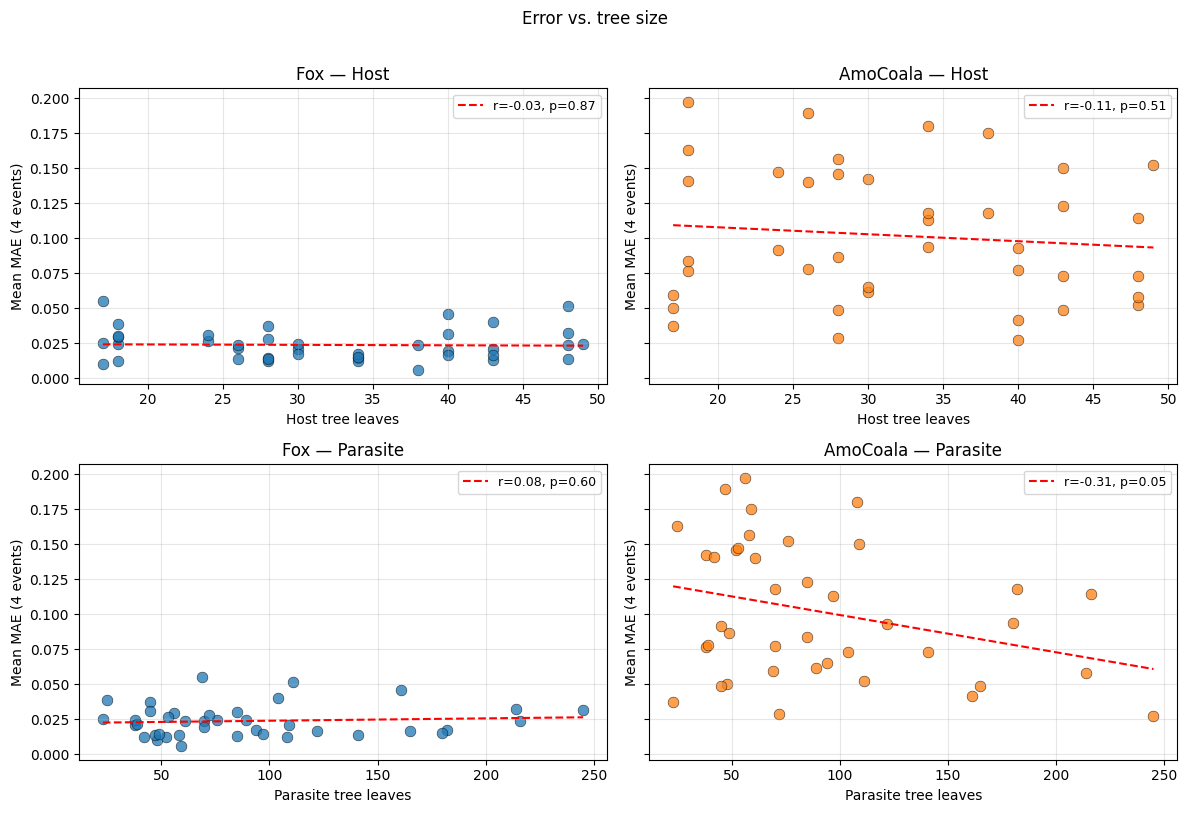


Binned MAE — Host leaves:
                  N  Fox MAE  AmoCoala MAE
Bin                                       
Small\n(≤26)     13   0.0265        0.1121
Medium\n(28–38)  14   0.0186        0.1097
Large\n(≥40)     13   0.0270        0.0835

Binned MAE — Parasite leaves:
                  N  Fox MAE  AmoCoala MAE
Bin                                       
Small\n(≤53)     13   0.0224        0.1077
Medium\n(56–94)  13   0.0239        0.1108
Large\n(≥97)     14   0.0253        0.0885


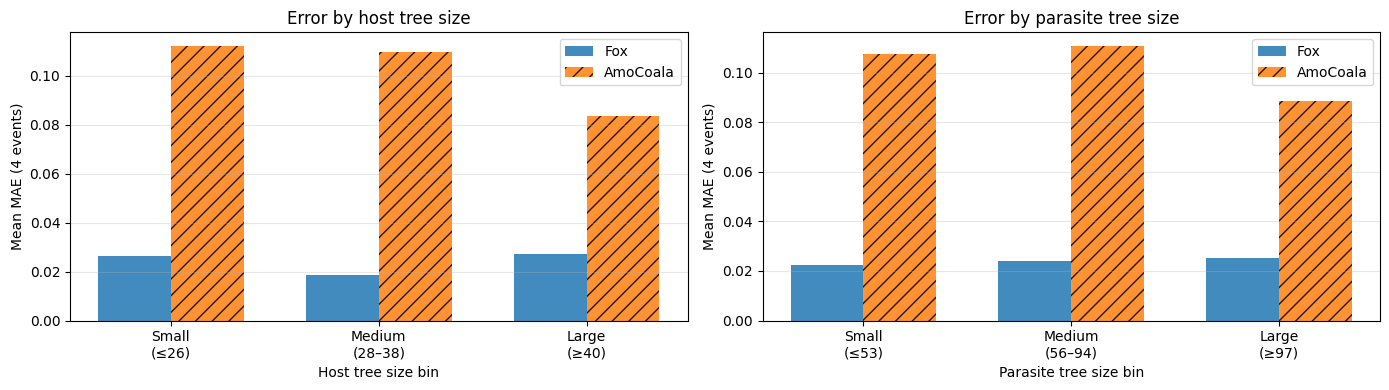

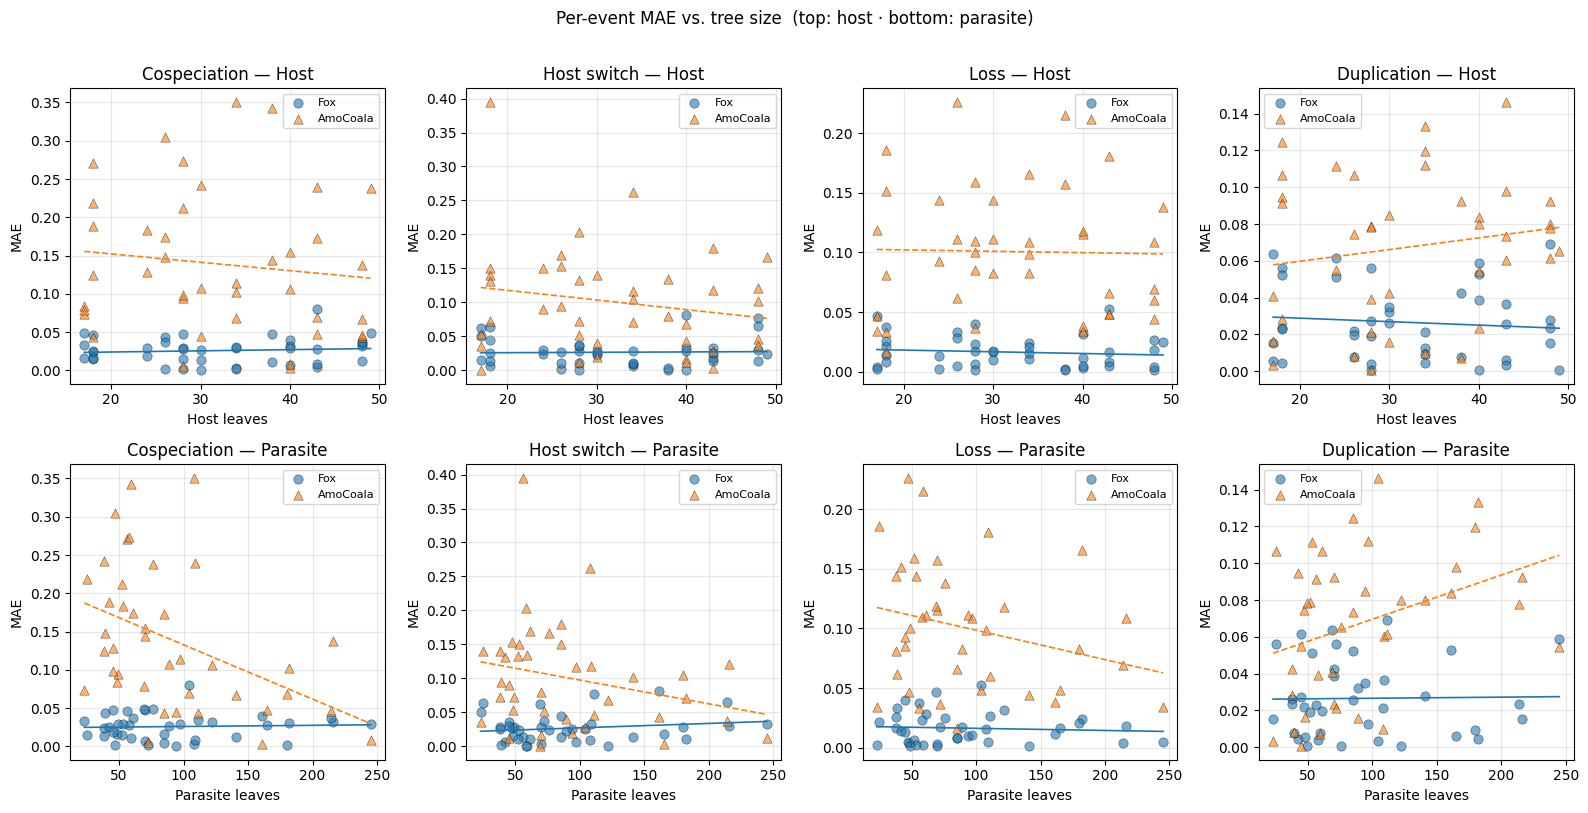

In [ ]:
# ── Performance vs. tree size (host & parasite) ───────────────────────────────
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats

TGL_DIR = "test_data/Datasets"

leaf_rows = []
for tgl in sorted(__import__('glob').glob(f"{TGL_DIR}/*.tgl")):
    txt = open(tgl).read()
    h = re.search(r"Host_num_leaves: (\d+)", txt)
    s = re.search(r"Symbiont_num_leaves: (\d+)", txt)
    if h and s:
        leaf_rows.append({
            "file": __import__('os').path.basename(tgl),
            "host_leaves": int(h.group(1)),
            "sym_leaves":  int(s.group(1)),
        })

df_leaves = pd.DataFrame(leaf_rows)
df_sz = df_cmp3.merge(df_leaves, on="file", how="inner")
print(f"Datasets with leaf info: {len(df_sz)}")

for model_name, prefix in [("Fox", "pred"), ("AmoCoala", "ac")]:
    df_sz[f"mae_{model_name}"] = np.mean(
        [np.abs(df_sz[f"{prefix}_{e}"] - df_sz[f"true_{e}"]) for e in EVENT_NAMES], axis=0
    )

TREE_DIMS = [("host_leaves", "Host"), ("sym_leaves", "Parasite")]

# ── Figure 1: scatter MAE vs tree size (2 rows = host/para, 2 cols = model) ──
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for row, (col_name, dim_label) in enumerate(TREE_DIMS):
    for ax, (model_name, color) in zip(axes[row], [("Fox", "C0"), ("AmoCoala", "C1")]):
        x = df_sz[col_name]
        y = df_sz[f"mae_{model_name}"]
        ax.scatter(x, y, alpha=0.75, s=60, color=color, edgecolors="k", linewidths=0.4)
        m, b, r, p, _ = stats.linregress(x, y)
        xl = np.array([x.min(), x.max()])
        ax.plot(xl, m * xl + b, "r--", lw=1.5, label=f"r={r:.2f}, p={p:.2f}")
        ax.set_xlabel(f"{dim_label} tree leaves")
        ax.set_ylabel("Mean MAE (4 events)")
        ax.set_title(f"{model_name} — {dim_label}")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
plt.suptitle("Error vs. tree size", y=1.01)
plt.tight_layout()
plt.savefig("test_data/error_vs_treesize_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Figure 2: binned MAE bar chart (side-by-side host / parasite) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (col_name, dim_label) in zip(axes, TREE_DIMS):
    bins_cat = pd.qcut(df_sz[col_name], q=3, labels=["Small", "Medium", "Large"])
    bin_summary = []
    for b in bins_cat.cat.categories:
        sub = df_sz[bins_cat == b]
        lo, hi = sub[col_name].min(), sub[col_name].max()
        label = f"{b}\n(≤{hi})" if b == "Small" else (f"{b}\n(≥{lo})" if b == "Large" else f"{b}\n({lo}–{hi})")
        bin_summary.append({"Bin": label, "N": len(sub),
                             "Fox MAE": sub["mae_Fox"].mean(),
                             "AmoCoala MAE": sub["mae_AmoCoala"].mean()})
    df_bin = pd.DataFrame(bin_summary).set_index("Bin")
    print(f"\nBinned MAE — {dim_label} leaves:")
    print(df_bin.round(4))
    x_pos = np.arange(len(df_bin)); w = 0.35
    ax.bar(x_pos - w/2, df_bin["Fox MAE"],  w, label="Fox",  color="C0", alpha=0.85)
    ax.bar(x_pos + w/2, df_bin["AmoCoala MAE"], w, label="AmoCoala", color="C1", alpha=0.85,
           hatch="//", edgecolor="black", linewidth=0)  # stripes: readable in B&W
    ax.set_xticks(x_pos); ax.set_xticklabels(df_bin.index)
    ax.set_ylabel("Mean MAE (4 events)")
    ax.set_xlabel(f"{dim_label} tree size bin")
    ax.set_title(f"Error by {dim_label.lower()} tree size")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("test_data/error_vs_treesize_binned.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Figure 3: per-event MAE vs tree size (2 rows = host/para, 4 cols = event) ─
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, (col_name, dim_label) in enumerate(TREE_DIMS):
    for ax, event in zip(axes[row], EVENT_NAMES):
        x = df_sz[col_name]
        # marker + line style per model: readable in B&W
        for model_key, color, marker, ls, lbl in [("pred", "C0", "o", "-",  "Fox"),
                                                  ("ac",   "C1", "^", "--", "AmoCoala")]:
            y = np.abs(df_sz[f"{model_key}_{event}"] - df_sz[f"true_{event}"])
            ax.scatter(x, y, alpha=0.6, s=45, color=color, marker=marker,
                       edgecolors="k", linewidths=0.4, label=lbl)
            m, b, r, p, _ = stats.linregress(x, y)
            xl = np.array([x.min(), x.max()])
            ax.plot(xl, m * xl + b, ls, color=color, lw=1.2)
        ax.set_title(f"{disp(event)} — {dim_label}")
        ax.set_xlabel(f"{dim_label} leaves")
        ax.set_ylabel("MAE")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
plt.suptitle("Per-event MAE vs. tree size  (top: host · bottom: parasite)", y=1.01)
plt.tight_layout()
plt.savefig("test_data/error_vs_treesize_per_event.png", dpi=120, bbox_inches="tight")
plt.show()


## Amocoala on sim_data with more rounds

In [ ]:
TGL_DIR    = "test_data/Datasets_small"
SIM_AC_DIR = "test_data/amocoala_small"
os.makedirs(SIM_AC_DIR, exist_ok=True)

AMOCOALA_JAR = os.environ.get("AMOCOALA_JAR", "/Users/gabriele/AmoCoala-main/AmoCoala.jar")
TEST_N_SIM   = None  # set to int to limit, e.g. 10
N_ROUNDS     = 3
T_VECTOR     = ",".join(["0.1"] * N_ROUNDS)  # -t needs one threshold per round

_STRIP_BL  = re.compile(r":[0-9eE+\-.]*[0-9]")
_STRIP_INT = re.compile(r"\)[A-Za-z0-9_]+")

def _parse_newick_subtrees(nwk):
    nwk = _STRIP_BL.sub("", nwk.strip().rstrip(";"))
    subtree_leaves = {}
    def parse(s, pos):
        if s[pos] == "(":
            pos += 1
            all_leaves = []
            while pos < len(s) and s[pos] != ")":
                child_leaves, pos, _ = parse(s, pos)
                all_leaves.extend(child_leaves)
                if pos < len(s) and s[pos] == ",":
                    pos += 1
            pos += 1
            name_start = pos
            while pos < len(s) and s[pos] not in ",)(":
                pos += 1
            node_name = s[name_start:pos].strip()
            if node_name:
                subtree_leaves[node_name] = set(all_leaves)
            return all_leaves, pos, node_name
        else:
            name_start = pos
            while pos < len(s) and s[pos] not in ",)":
                pos += 1
            leaf_name = s[name_start:pos].strip()
            if leaf_name:
                subtree_leaves[leaf_name] = {leaf_name}
            return [leaf_name], pos, leaf_name
    parse(nwk, 0)
    return subtree_leaves

def _collapse_unary(nwk):
    # AmoCoala's addVerticalSpread only handles binary internal nodes (Tree.java:1018).
    # Unary internals -> entries missing from mapVerticalSpreadAssociations -> NPE at line 1125.
    nwk = nwk.strip().rstrip(";")
    pos = [0]
    def parse():
        if pos[0] < len(nwk) and nwk[pos[0]] == "(":
            pos[0] += 1
            ch = [parse()]
            while pos[0] < len(nwk) and nwk[pos[0]] == ",":
                pos[0] += 1; ch.append(parse())
            pos[0] += 1  # )
            ns = pos[0]
            while pos[0] < len(nwk) and nwk[pos[0]] not in ",()":
                pos[0] += 1
            return (nwk[ns:pos[0]], ch)
        ns = pos[0]
        while pos[0] < len(nwk) and nwk[pos[0]] not in ",()":
            pos[0] += 1
        return (nwk[ns:pos[0]], None)
    def simplify(node):
        label, ch = node
        if ch is None: return node
        new_ch = [simplify(c) for c in ch]
        if len(new_ch) == 1: return new_ch[0]
        return (label, new_ch)
    def ser(node):
        label, ch = node
        if ch is None: return label
        return "(" + ",".join(ser(c) for c in ch) + ")" + label
    return ser(simplify(parse()))

def _expand_dist(distribution, host_nwk):
    st = _parse_newick_subtrees(host_nwk)
    all_leaves = {n for n, v in st.items() if v == {n}}
    expanded, seen = [], set()
    for p, h in distribution:
        targets = [h] if h in all_leaves else sorted(st.get(h, []))
        for t in targets:
            if (p, t) not in seen:
                expanded.append((p, t))
                seen.add((p, t))
    return expanded

def run_amocoala_on_tgl(tgl_path, out_dir, n_rounds=N_ROUNDS, t_vector=T_VECTOR):
    os.makedirs(out_dir, exist_ok=True)
    stem       = os.path.splitext(os.path.basename(tgl_path))[0]
    nex_path   = os.path.join(out_dir, f"{stem}.nex")
    result_csv = f"{nex_path}.accep.round_{n_rounds}.csv"
    if os.path.exists(result_csv):
        return result_csv, None
    d = parse_tgl(tgl_path)
    if d["host_tree"] is None or d["para_tree"] is None:
        return None, "Could not parse trees"
    expanded_dist = _expand_dist(d["distribution"], d["host_tree"])
    host_nwk = _collapse_unary(_STRIP_INT.sub(")", _STRIP_BL.sub("", d["host_tree"])))
    para_nwk = _collapse_unary(_STRIP_INT.sub(")", _STRIP_BL.sub("", d["para_tree"])))
    host_leaves = {n for n, v in _parse_newick_subtrees(host_nwk).items() if v == {n}}
    para_leaves = {n for n, v in _parse_newick_subtrees(para_nwk).items() if v == {n}}
    expanded_dist = [(p, h) for p, h in expanded_dist if p in para_leaves and h in host_leaves]
    if len(expanded_dist) < 3:
        return None, f"Too few valid leaf mappings: {len(expanded_dist)}"
    map_strs = [f"{p} : {h}" for p, h in expanded_dist]
    nexus = (
        "#NEXUS\n"
        f"BEGIN HOST;\n\tTREE HOST = {host_nwk};\nENDBLOCK;\n"
        f"BEGIN PARASITE;\n\tTREE PARASITE = {para_nwk};\nENDBLOCK;\n"
        "BEGIN DISTRIBUTION;\n\tRANGE\n\t\t"
        + ", ".join(map_strs)
        + ";\nENDBLOCK;\n"
    )
    with open(nex_path, "w") as f:
        f.write(nexus)
    r = subprocess.run(
        f"java -jar {AMOCOALA_JAR} -input {nex_path} -N 1000 -M 100 -R {n_rounds} -t {t_vector}",
        shell=True, capture_output=True, text=True, timeout=6000)
    if os.path.exists(result_csv):
        return result_csv, None
    return None, (r.stderr or r.stdout)[:300]


all_tgls = sorted(glob.glob(os.path.join(TGL_DIR, "*.tgl")))
if TEST_N_SIM and TEST_N_SIM < len(all_tgls):
    idx = [round(i * (len(all_tgls) - 1) / (TEST_N_SIM - 1)) for i in range(TEST_N_SIM)]
    run_tgls = [all_tgls[i] for i in idx]
else:
    run_tgls = all_tgls

print(f"Running AmoCoala on {len(run_tgls)} datasets ({N_ROUNDS} rounds, true trees, no IQ-TREE):")

def _run_one(args):
    tgl_path, out_dir = args
    t0 = time.time()
    print(f"[{time.strftime('%H:%M:%S')}] START {os.path.basename(tgl_path)}", flush=True)
    csv, err = run_amocoala_on_tgl(tgl_path, out_dir)
    elapsed = time.time() - t0
    status = 'OK' if csv else 'FAIL'
    print(f"[{time.strftime('%H:%M:%S')}] {status} {os.path.basename(tgl_path)} ({elapsed:.0f}s)", flush=True)
    return tgl_path, csv, err

jobs = [(p, os.path.join(SIM_AC_DIR, os.path.splitext(os.path.basename(p))[0])) for p in run_tgls]
failed_sim = []
with ThreadPoolExecutor(max_workers=min(len(run_tgls), os.cpu_count())) as ex:
    futures = {ex.submit(_run_one, j): j for j in jobs}
    for fut in tqdm(as_completed(futures), total=len(jobs)):
        tgl_path, csv, err = fut.result()
        if csv is None:
            failed_sim.append((os.path.basename(tgl_path), err))

n_done = len(run_tgls) - len(failed_sim)
print(f"\nDone: {n_done} / {len(run_tgls)}")
if failed_sim:
    print("Failed:", failed_sim)







Running AmoCoala on 5 datasets (3 rounds, true trees, no IQ-TREE):
[09:33:07] START Dataset16.tgl
[09:33:07] START Dataset36.tgl
[09:33:07] START Dataset37.tgl
[09:33:07] START Dataset49.tgl
[09:33:07] OK Dataset16.tgl (0s)
[09:33:07] START Dataset57.tgl
[09:33:07] OK Dataset36.tgl (0s)
[09:33:07] OK Dataset49.tgl (0s)
[09:33:07] OK Dataset57.tgl (0s)
[09:33:07] OK Dataset37.tgl (0s)


100%|██████████| 5/5 [00:00<00:00, 75983.77it/s]


Done: 5 / 5


In [ ]:
# Reuse predictions from df (cell In[4]) — already ran model on all .pt in DATA_DIR.
# Map each .tgl -> matching .pt by event_frequencies tuple, then filter df.
PT_DIR = DATA_DIR  # same folder used by In[4]

_FREQ_FIELDS = ["Speciation", "HGT", "Loss", "Duplication", "Sim_time"]
def _label_key(freqs):
    return tuple(round(float(freqs.get(k, 0.0)), 5) for k in _FREQ_FIELDS)

pt_index = {}
for p in sorted(glob.glob(os.path.join(PT_DIR, "*.pt"))):
    s = torch.load(p, map_location="cpu", weights_only=False)
    freqs = s.get("event_frequencies") or s.get("labels")
    if isinstance(freqs, dict):
        pt_index[_label_key(freqs)] = os.path.basename(p)

run_tgls = all_tgls
pt_to_tgl_name, missing = {}, []
for tgl in run_tgls:
    freqs = parse_tgl(tgl)["event_freqs"]
    pt_name = pt_index.get(_label_key(freqs))
    if pt_name is None:
        missing.append(os.path.basename(tgl))
    else:
        pt_to_tgl_name[pt_name] = os.path.basename(tgl)
if missing:
    print(f"WARNING: no .pt match for {len(missing)} tgls: {missing[:5]}...")

df_tgl_pred = df[df["file"].isin(pt_to_tgl_name)].copy()
df_tgl_pred["file"] = df_tgl_pred["file"].map(pt_to_tgl_name)
print("reused", len(df_tgl_pred), "predictions from df (no re-inference)")

reused 5 predictions from df (no re-inference)


In [ ]:
# ── Parse AmoCoala results + 3-way comparison ─────────────────────
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import r2_score

SIM_AC_DIR = "test_data/amocoala_small"
def _parse_ac_csv(csv_path):
    rows = []
    with open(csv_path) as f:
        for line in f:
            vals = [float(x) for x in line.strip().split("\t") if x.strip()]
            if len(vals) >= 4:
                rows.append(vals)
    if not rows:
        return None
    arr = np.array(rows)
    cospec, dup, hsw, loss = arr[:,0].mean(), arr[:,1].mean(), arr[:,2].mean(), arr[:,3].mean()
    total = cospec + dup + hsw + loss or 1.0
    return {"Speciation": cospec/total, "Duplication": dup/total,
            "HGT": hsw/total, "Loss": loss/total}

ac_rows = []
for tgl_path in run_tgls:
    stem = os.path.splitext(os.path.basename(tgl_path))[0]
    csv  = os.path.join(SIM_AC_DIR, stem, f"{stem}.nex.accep.round_3.csv")
    if not os.path.exists(csv):
        continue
    freqs = _parse_ac_csv(csv)
    if freqs is None:
        continue
    true = parse_tgl(tgl_path)["event_freqs"]
    row  = {"file": f"{stem}.tgl"}
    row.update({f"ac_{e}":   freqs.get(e, float("nan")) for e in EVENT_NAMES})
    row.update({f"true_{e}": true.get(e,  float("nan")) for e in EVENT_NAMES})
    ac_rows.append(row)

df_sac  = pd.DataFrame(ac_rows)
df_cmp3 = df_sac.merge(
    df_tgl_pred[["file"] + [f"pred_{e}" for e in EVENT_NAMES]],
    on="file", how="inner")
print(f"Matched: {len(df_cmp3)} samples")
print(df_cmp3[["file"]
              + [f"true_{e}" for e in EVENT_NAMES]
              + [f"ac_{e}"   for e in EVENT_NAMES]
              + [f"pred_{e}" for e in EVENT_NAMES]].to_string(index=False))

rows_ac, rows_mdl = [], []
for event in EVENT_NAMES:
    t = df_cmp3[f"true_{event}"].values
    a = df_cmp3[f"ac_{event}"].values
    p = df_cmp3[f"pred_{event}"].values
    rows_ac.append({"Event": event,
        "MAE":  np.abs(a-t).mean(), 'MRE': np.abs(a-t).mean() / np.mean(t) if np.mean(t) > 0 else 1e-6,
        'RMSE': np.sqrt(((a-t)**2).mean()),
        "R2":   r2_score(t, a),     "Pearson r": stats.pearsonr(t, a)[0]})
    rows_mdl.append({"Event": event,
        "MAE":  np.abs(p-t).mean(), 'MRE': np.abs(p-t).mean() / np.mean(t) if np.mean(t) > 0 else 1e-6,
        'RMSE': np.sqrt(((p-t)**2).mean()),
        "R2":   r2_score(t, p),     "Pearson r": stats.pearsonr(t, p)[0]})

df_mtr_ac  = pd.DataFrame(rows_ac).set_index("Event")
df_mtr_mdl = pd.DataFrame(rows_mdl).set_index("Event")
print("\n=== AmoCoala vs truth ===")
print(df_mtr_ac.round(4))
print("\n=== Model vs truth (same subset) ===")
print(df_mtr_mdl.round(4))

Matched: 5 samples
         file  true_Speciation  true_HGT  true_Loss  true_Duplication  ac_Speciation   ac_HGT  ac_Loss  ac_Duplication  pred_Speciation  pred_HGT  pred_Loss  pred_Duplication
Dataset16.tgl           0.7568    0.1081     0.0270            0.1081       0.858030 0.015310 0.054560        0.072100         0.743476  0.079055   0.043344          0.134125
Dataset36.tgl           0.7083    0.0833     0.0000            0.2083       0.896482 0.096648 0.004270        0.002600         0.693535  0.019884   0.021910          0.264671
Dataset37.tgl           0.6216    0.1081     0.1351            0.1351       0.757242 0.070049 0.055319        0.117389         0.645790  0.133739   0.109018          0.111453
Dataset49.tgl           0.5909    0.0909     0.1818            0.1364       0.919581 0.008840 0.012020        0.059559         0.557244  0.142080   0.179734          0.120942
Dataset57.tgl           0.6579    0.0526     0.1842            0.1053       0.842832 0.116499 0.004140    

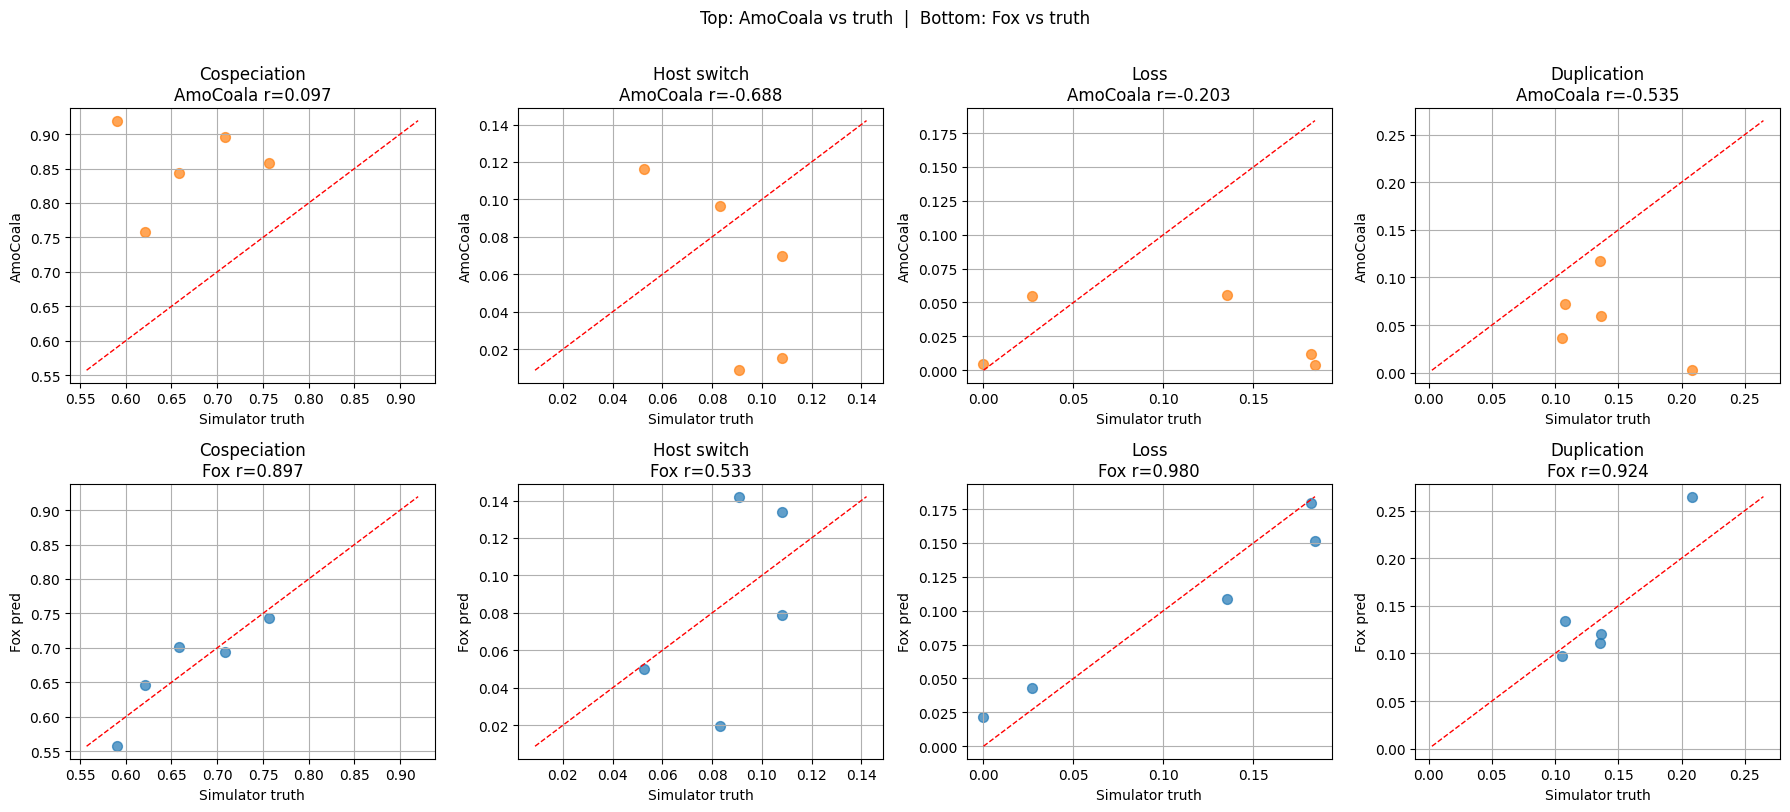

In [ ]:
# ── 3-way scatter: truth vs AmoCoala vs model ────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col, event in enumerate(EVENT_NAMES):
    t = df_cmp3[f'true_{event}'].values
    a = df_cmp3[f'ac_{event}'].values
    p = df_cmp3[f'pred_{event}'].values
    lo = min(t.min(), a.min(), p.min())
    hi = max(t.max(), a.max(), p.max())
    ax = axes[0, col]
    ax.scatter(t, a, alpha=0.7, s=50, color='C1')
    ax.plot([lo,hi], [lo,hi], 'r--', lw=1)
    r_ac = stats.pearsonr(t, a)[0]
    ax.set_title(f'{disp(event)}\nAmoCoala r={r_ac:.3f}')
    ax.set_xlabel('Simulator truth'); ax.set_ylabel('AmoCoala'); ax.grid(True)
    ax = axes[1, col]
    ax.scatter(t, p, alpha=0.7, s=50, color='C0')
    ax.plot([lo,hi], [lo,hi], 'r--', lw=1)
    r_mdl = stats.pearsonr(t, p)[0]
    ax.set_title(f'{disp(event)}\nFox r={r_mdl:.3f}')
    ax.set_xlabel('Simulator truth'); ax.set_ylabel('Fox pred'); ax.grid(True)
plt.suptitle('Top: AmoCoala vs truth  |  Bottom: Fox vs truth', y=1.01)
plt.tight_layout()
plt.savefig("test_data/amocoala_vs_fox_3rounds.png", dpi=120, bbox_inches="tight")
plt.show()


## Real-data test: Heliconius Müllerian mimicry


In [ ]:
# ── 1. Show dataset contents ──────────────────────────────────────────────────
import pandas as pd

TGL_PATH = "test_data/real_data/heliconius_mimicry.tgl"
NEX_PATH = "test_data/real_data/heliconius.nex"
MAP_PATH = "test_data/real_data/heliconius_specimen_map.xlsx"

d = parse_tgl(TGL_PATH)
host_msa  = d["host_msa"]
para_msa  = d["para_msa"]
dist_pairs = d["distribution"]

# Specimen cross-reference
spec_map = pd.read_excel(MAP_PATH)
short_to_fig = dict(zip(spec_map["Short_name"], spec_map["Name_figure"]))

print("HOST (H. erato)")
for s in host_msa:
    print(f"  {s:12s}  {short_to_fig.get(s,'')}")

print()
print("PARASITE (H. melpomene) ")
for s in para_msa:
    print(f"  {s:12s}  {short_to_fig.get(s,'')}")

print()
print("Associations")
for p, h in dist_pairs:
    print(f"  {p:12s} : {h:12s}   {short_to_fig.get(p,''):25s} ↔ {short_to_fig.get(h,'')}")


HOST (H. erato)
  Herato25      emma (East Pe)
  Herato48      favorinus (East Pe)
  Herato38      etylus (East E)
  Herato75      lativitta (East E)
  Herato30      erato (East FG)
  Herato61      hydara (East FG)
  Herato69      hydara (East T)
  Herato65      hydara (West Pa)
  Herato81      petiverana (West CR)
  Herato87      petiverana (West Pa)
  Herato56      hydara (East C)
  Herato21      cyrbia (West E)

PARASITE (H. melpomene) 
  Hmelpo98      aglaope (East Pe)
  Hmelp102      amaryllis (East Pe)
  Hmelp110      ecuadoriensis (East E)
  Hmelp246      malleti (East E)
  Hmelp161      thelxiopeia (East FG)
  Hmelp129      melpomene (East FG)
  Hmelp168      melpomene (East T)
  Hmelp132      melpomene (West Pa)
  Hmelp136      rosina (West CR)
  Hmelp133      rosina (West Pa)
  Hmelp100      melpomene (East C)
  Hmelp134      cythera (West E)

Associations
  Hmelp134     : Herato21       cythera (West E)          ↔ cyrbia (West E)
  Hmelp136     : Herato81       rosina (West 

In [ ]:
# ── 3a. Fox prediction ────────────────────────────────────────────────────
import torch

host_tok = torch.stack([encode_sequence(seq) for seq in host_msa.values()])
para_tok = torch.stack([encode_sequence(seq) for seq in para_msa.values()])
host_dist_t = jukes_cantor_dist(host_tok)
para_dist_t = jukes_cantor_dist(para_tok)
h_idx2 = {n: i for i, n in enumerate(host_msa)}
p_idx2 = {n: i for i, n in enumerate(para_msa)}
mappings = [(h_idx2[h], p_idx2[p]) for p, h in dist_pairs if p in p_idx2 and h in h_idx2]

with torch.no_grad():
    out = model(
        host_tok.unsqueeze(0).to(device),
        para_tok.unsqueeze(0).to(device),
        [mappings],
        host_dist=host_dist_t.unsqueeze(0).to(device),
        para_dist=para_dist_t.unsqueeze(0).to(device),
    )

fox_pred = dict(zip(EVENT_NAMES, out.squeeze(0).cpu().tolist()))
print("Fox prediction on Heliconius mimicry dataset:")
print(f"  {'Event':12s}  {'Prediction':>10s}")
print(f"  {'-'*25}")
for e, v in fox_pred.items():
    print(f"  {e:12s}  {v:10.4f}")
print(f"\n  Dominant signal: {max(fox_pred, key=fox_pred.get)} ({max(fox_pred.values()):.1%})")

Fox prediction on Heliconius mimicry dataset:
  Event         Prediction
  -------------------------
  Speciation        0.7765
  HGT               0.0401
  Loss              0.0017
  Duplication       0.1817

  Dominant signal: Speciation (77.6%)


In [ ]:
# ── 3b. AmoCoala on heliconius.nex ───────────────────────────────────────────
import subprocess, os

AMOCOALA_JAR = os.environ.get("AMOCOALA_JAR", "/Users/gabriele/AmoCoala-main/AmoCoala.jar")
NEX = "test_data/real_data/heliconius.nex"
R = 3
AC_CSV = NEX + f".accep.round_{R}.csv"

if not os.path.exists(AC_CSV):
    print("Running AmoCoala...")
    r = subprocess.run(
        f'java -jar {AMOCOALA_JAR} -input {NEX} -N 2000 -M 100 -R {R} -t 0.1,0.25,0.25',
        shell=True, capture_output=True, text=True, timeout=6000
    )
    print(r.stdout[-500:] if r.stdout else "")
    print(r.stderr[-500:] if r.stderr else "")
else:
    print(f"Reusing existing result: {AC_CSV}")

# Parse AmoCoala result (final round = posterior)
if os.path.exists(AC_CSV):
    rows = []
    with open(AC_CSV) as f:
        for line in f:
            vals = [float(x) for x in line.strip().split("\t") if x.strip()]
            if len(vals) >= 4:
                rows.append(vals)
    arr = np.array(rows)
    cospec, dup, hsw, loss = arr[:,0].mean(), arr[:,1].mean(), arr[:,2].mean(), arr[:,3].mean()
    total = cospec + dup + hsw + loss or 1.0
    ac_pred = {
        "Speciation":  cospec / total,
        "HGT":         hsw    / total,
        "Loss":        loss   / total,
        "Duplication": dup    / total,
    }
    print(f"\nAmoCoala result ({len(rows)} accepted solutions, round {R}):")
    print(f"  {'Event':12s}  {'Prediction':>10s}")
    print(f"  {'-'*25}")
    for e, v in ac_pred.items():
        print(f"  {e:12s}  {v:10.4f}")
    print(f"\n  Dominant signal: {max(ac_pred, key=ac_pred.get)} ({max(ac_pred.values()):.1%})")
else:
    ac_pred = None
    print("AmoCoala did not produce output.")


Reusing existing result: test_data/real_data/heliconius.nex.accep.round_3.csv

AmoCoala result (50 accepted solutions, round 3):
  Event         Prediction
  -------------------------
  Speciation        0.6076
  HGT               0.1576
  Loss              0.2111
  Duplication       0.0236

  Dominant signal: Speciation (60.8%)


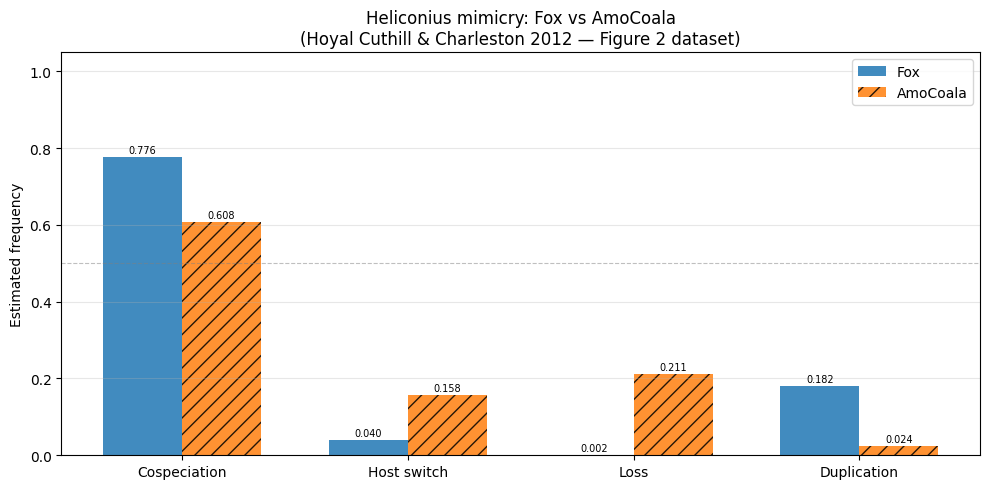

Saved: test_data/heliconius_fox_vs_amocoala.png

Summary:
  Event              Fox  AmoCoala
  --------------------------------
  Speciation      0.7765    0.6076
  HGT             0.0401    0.1576
  Loss            0.0017    0.2111
  Duplication     0.1817    0.0236

  Expected: tools should agree on high Speciation
  (parallel cospeciation = textbook case for this dataset)


In [ ]:
# ── 4. Compare Fox vs AmoCoala on real Heliconius data ──
import matplotlib.pyplot as plt
import numpy as np

if ac_pred is None:
    print("AmoCoala result not available — skipping comparison.")
else:
    events = EVENT_NAMES
    x = np.arange(len(events))
    w = 0.35
    series = [
        ("Fox",      fox_pred, "C0", -w/2, None),
        ("AmoCoala", ac_pred,  "C1",  w/2, "//"),  # stripes: readable in B&W
    ]

    fig, ax = plt.subplots(figsize=(10, 5))
    for name, pred, color, off, hatch in series:
        bars = ax.bar(x + off, [pred[e] for e in events], w,
                      label=name, color=color, alpha=0.85,
                      hatch=hatch, edgecolor="black", linewidth=0)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f"{h:.3f}",
                    ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x); ax.set_xticklabels([disp(e) for e in events])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Estimated frequency")
    ax.set_title("Heliconius mimicry: Fox vs AmoCoala\n"
                 "(Hoyal Cuthill & Charleston 2012 — Figure 2 dataset)")
    ax.legend()
    ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("test_data/heliconius_fox_vs_amocoala.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: test_data/heliconius_fox_vs_amocoala.png")

    # ── Summary table ──────────────────────────────────────────────────────────
    print("\nSummary:")
    print(f"  {'Event':12s}  {'Fox':>8s}  {'AmoCoala':>8s}")
    print(f"  {'-'*32}")
    for e in events:
        print(f"  {e:12s}  {fox_pred[e]:8.4f}  {ac_pred[e]:8.4f}")
    print()
    print("  Expected: tools should agree on high Speciation")
    print("  (parallel cospeciation = textbook case for this dataset)")

## Leaf-removal experiment: dropping Hmelp246

One symbiont specimen (*H. melpomene malleti*, `Hmelp246`, East Ecuador) is ~76% gaps
over the full alignment and 100% gaps within the first 250 columns Fox reads
(`MAX_SEQ_LEN = 250`), so it carries no phylogenetic signal. We drop it and re-run
**both** Fox and AmoCoala to see whether the cospeciation-dominated profile sharpens,
and whether the effect is specific to Fox's fixed input window or reflects the
specimen itself.

In [ ]:
# -- Leaf-removal: Fox WITHOUT the Hmelp246 <-> its host association pair --
DROP = "Hmelp246"
DROP_HOST = next(h for (p, h) in dist_pairs if p == DROP)   # = Herato75
print(f"Removing association pair: {DROP} <-> {DROP_HOST}")

para_msa_nl   = {k: v for k, v in para_msa.items() if k != DROP}
host_msa_nl   = {k: v for k, v in host_msa.items() if k != DROP_HOST}
dist_pairs_nl = [(p, h) for (p, h) in dist_pairs if p != DROP and h != DROP_HOST]

host_tok_nl = torch.stack([encode_sequence(seq) for seq in host_msa_nl.values()])
para_tok_nl = torch.stack([encode_sequence(seq) for seq in para_msa_nl.values()])
host_dist_nl = jukes_cantor_dist(host_tok_nl)
para_dist_nl = jukes_cantor_dist(para_tok_nl)
h_idx_nl = {n: i for i, n in enumerate(host_msa_nl)}
p_idx_nl = {n: i for i, n in enumerate(para_msa_nl)}
map_nl = [(h_idx_nl[h], p_idx_nl[p]) for p, h in dist_pairs_nl if p in p_idx_nl and h in h_idx_nl]

with torch.no_grad():
    out_nl = model(
        host_tok_nl.unsqueeze(0).to(device),
        para_tok_nl.unsqueeze(0).to(device),
        [map_nl],
        host_dist=host_dist_nl.unsqueeze(0).to(device),
        para_dist=para_dist_nl.unsqueeze(0).to(device),
    )
fox_pred_nl = dict(zip(EVENT_NAMES, out_nl.squeeze(0).cpu().tolist()))
print(f"Fox WITHOUT {DROP} (+ host {DROP_HOST}):")
for e, v in fox_pred_nl.items():
    print(f"  {e:12s}  {v:10.4f}")
print(f"\n  Dominant: {max(fox_pred_nl, key=fox_pred_nl.get)} "
      f"({max(fox_pred_nl.values()):.1%})")

Removing association pair: Hmelp246 <-> Herato75
Fox WITHOUT Hmelp246 (+ host Herato75):
  Speciation        0.8098
  HGT               0.0643
  Loss              0.0147
  Duplication       0.1111

  Dominant: Speciation (81.0%)


In [ ]:
# -- Auto-build the pruned .nex for AmoCoala (no extra dependencies) --
# Removes the whole association pair: the parasite leaf Hmelp246 AND its host.
import re

SRC_NEX = "test_data/real_data/heliconius.nex"
NEX_NL  = "test_data/real_data/filtered/heliconius_no_Hmelp246.nex"
DROP    = "Hmelp246"

def _parse_newick(s):
    s = s.strip().rstrip(";"); pos = 0
    def parse():
        nonlocal pos
        if s[pos] == "(":
            pos += 1; kids = []
            while True:
                kids.append(parse())
                if s[pos] == ",": pos += 1
                elif s[pos] == ")": pos += 1; break
            return kids
        start = pos
        while pos < len(s) and s[pos] not in ",()": pos += 1
        return s[start:pos]
    return parse()

def _prune(node, drop):
    if isinstance(node, str):
        return None if node == drop else node
    kids = [k for k in (_prune(c, drop) for c in node) if k is not None]
    if not kids: return None
    if len(kids) == 1: return kids[0]        # collapse unary node
    return kids

def _to_newick(node):
    if isinstance(node, str): return node
    return "(" + ",".join(_to_newick(c) for c in node) + ")"

raw  = open(SRC_NEX).read()
host = re.search(r"TREE\s+HOST\s*=\s*(.+?);", raw, re.S).group(1).strip()
par  = re.search(r"TREE\s+PARASITE\s*=\s*(.+?);", raw, re.S).group(1).strip()
rng  = re.search(r"RANGE\s*(.+?);", raw, re.S).group(1)

pairs     = [p.strip() for p in rng.split(",") if p.strip()]
DROP_HOST = next(p.split(":")[1].strip() for p in pairs if p.split(":")[0].strip() == DROP)
print(f"Removing association pair: {DROP} <-> {DROP_HOST}")

par_pruned  = _to_newick(_prune(_parse_newick(par),  DROP))
host_pruned = _to_newick(_prune(_parse_newick(host), DROP_HOST))

pairs_nl = [p for p in pairs
            if p.split(":")[0].strip() != DROP and p.split(":")[1].strip() != DROP_HOST]
range_nl = ",\n\t\t".join(pairs_nl)

nex = (
    "#NEXUS\n"
    "BEGIN HOST;\n"
    f"\tTREE HOST = {host_pruned};\n"
    "ENDBLOCK;\n"
    "BEGIN PARASITE;\n"
    f"\tTREE PARASITE = {par_pruned};\n"
    "ENDBLOCK;\n"
    "BEGIN DISTRIBUTION;\n"
    f"\tRANGE\n\t\t{range_nl};\n"
    "ENDBLOCK;\n"
)
open(NEX_NL, "w").write(nex)
assert DROP not in nex and DROP_HOST not in nex, "a dropped taxon is still present!"
print(f"Wrote {NEX_NL}  ({len(pairs_nl)} associations; {DROP} and {DROP_HOST} removed)\n")
print(nex)

Removing association pair: Hmelp246 <-> Herato75
Wrote test_data/real_data/filtered/heliconius_no_Hmelp246.nex  (11 associations; Hmelp246 and Herato75 removed)

#NEXUS
BEGIN HOST;
	TREE HOST = (((Herato25,(Herato48,Herato38)),(Herato30,Herato61)),((((Herato69,Herato65),Herato81),Herato87),(Herato56,Herato21)));
ENDBLOCK;
BEGIN PARASITE;
	TREE PARASITE = ((((Hmelpo98,Hmelp102),Hmelp110),((Hmelp161,Hmelp129),Hmelp168)),(((Hmelp132,Hmelp136),Hmelp133),(Hmelp100,Hmelp134)));
ENDBLOCK;
BEGIN DISTRIBUTION;
	RANGE
		Hmelp134 : Herato21,
		Hmelp136 : Herato81,
		Hmelp133 : Herato87,
		Hmelp132 : Herato65,
		Hmelp100 : Herato56,
		Hmelp168 : Herato69,
		Hmelp129 : Herato61,
		Hmelp161 : Herato30,
		Hmelpo98 : Herato25,
		Hmelp102 : Herato48,
		Hmelp110 : Herato38;
ENDBLOCK;



In [ ]:
# -- Leaf-removal: AmoCoala WITHOUT Hmelp246 --
AMOCOALA_JAR = os.environ.get("AMOCOALA_JAR", "/Users/gabriele/AmoCoala-main/AmoCoala.jar")
# The pruned .nex is created automatically by the previous cell; this one just
# runs AmoCoala on it and parses the result (same settings as the full run).
NEX_NL   = "test_data/real_data/filtered/heliconius_no_Hmelp246.nex"
R        = 3
AC_CSV_NL = NEX_NL + f".accep.round_{R}.csv"

ac_pred_nl = None
if os.path.exists(NEX_NL):
    if not os.path.exists(AC_CSV_NL):
        print("Running AmoCoala (no Hmelp246)...")
        r = subprocess.run(
            f'java -jar {AMOCOALA_JAR} -input {NEX_NL} -N 2000 -M 100 -R {R} -t 0.1,0.25,0.25',
            shell=True, capture_output=True, text=True, timeout=6000)
        print(r.stdout[-500:] if r.stdout else "")
        print(r.stderr[-300:] if r.stderr else "")
    if os.path.exists(AC_CSV_NL):
        rows = []
        with open(AC_CSV_NL) as f:
            for line in f:
                vals = [float(x) for x in line.strip().split("\t") if x.strip()]
                if len(vals) >= 4:
                    rows.append(vals)
        arr = np.array(rows)
        cospec, dup, hsw, loss = arr[:,0].mean(), arr[:,1].mean(), arr[:,2].mean(), arr[:,3].mean()
        tot = cospec + dup + hsw + loss or 1.0
        ac_pred_nl = {"Speciation": cospec/tot, "HGT": hsw/tot,
                      "Loss": loss/tot, "Duplication": dup/tot}
        print(f"AmoCoala WITHOUT Hmelp246 ({len(rows)} solutions):")
        for e, v in ac_pred_nl.items():
            print(f"  {e:12s}  {v:10.4f}")
else:
    print(f"Pruned .nex not found: {NEX_NL}\nCreate it, then re-run this cell.")

AmoCoala WITHOUT Hmelp246 (50 solutions):
  Speciation        0.7512
  HGT               0.1152
  Loss              0.1120
  Duplication       0.0215


In [ ]:
# -- Leaf-removal comparison: Fox / AmoCoala, with vs without Hmelp246 --
def _row(name, p):
    if p is None:
        return f"  {name:24s}  " + "     n/a" * len(EVENT_NAMES)
    return f"  {name:24s}  " + "".join(f"{p[e]:8.4f}" for e in EVENT_NAMES)

print(f"  {'':24s}  " + "".join(f"{disp(e):>8s}" for e in EVENT_NAMES))
print("  " + "-" * 56)
print(_row("Fox (full)",            fox_pred))
print(_row("Fox (no Hmelp246)",     fox_pred_nl))
print(_row("AmoCoala (full)",       ac_pred))
print(_row("AmoCoala (no Hmelp246)", ac_pred_nl))

                            CospeciationHost switch    LossDuplication
  --------------------------------------------------------
  Fox (full)                  0.7765  0.0401  0.0017  0.1817
  Fox (no Hmelp246)           0.8098  0.0643  0.0147  0.1111
  AmoCoala (full)             0.6076  0.1576  0.2111  0.0236
  AmoCoala (no Hmelp246)      0.7512  0.1152  0.1120  0.0215


## Robustness to alignment length

Fox reads a fixed window of `MAX_SEQ_LEN = 250` columns (shorter alignments are
padded; longer ones are truncated). Here we probe how accuracy depends on the
number of informative columns: for each held-out test dataset we truncate every
sequence to `k` columns (k = 50, 100, 150, 200, 250), pad back to the 250 window,
re-run Fox, and score against the ground truth. This isolates the effect of
alignment length (same sites, fewer of them). Testing lengths **beyond** 250 would
require raising `MAX_SEQ_LEN` and retraining, since the window is fixed.

In [ ]:
# -- Length sweep: truncate test MSAs to k columns, re-score Fox --
import glob, numpy as np, pandas as pd

EVENT_NAMES = ["Speciation", "HGT", "Loss", "Duplication"]
LENS  = [50, 100, 150, 200, 250]
files = sorted(glob.glob(f"{DATA_DIR}/*.pt"))

def _pred_at_len(hm, pm, maps, k):
    ht = torch.stack([encode_sequence(s[:k]) for s in hm.values()])   # first k cols, pad to 250
    pt = torch.stack([encode_sequence(s[:k]) for s in pm.values()])
    with torch.no_grad():
        o = model(ht.unsqueeze(0).to(device), pt.unsqueeze(0).to(device), [maps],
                  host_dist=jukes_cantor_dist(ht).unsqueeze(0).to(device),
                  para_dist=jukes_cantor_dist(pt).unsqueeze(0).to(device))
    return o.squeeze(0).cpu().tolist()

sweep = {L: {"pred": [], "true": []} for L in LENS}
for i, f in enumerate(files):
    s = torch.load(f, map_location="cpu", weights_only=False)
    hm, pm = s["host_msas"], s["parasite_msas"]
    hi = {n: j for j, n in enumerate(hm)}; pi = {n: j for j, n in enumerate(pm)}
    raw = s["mappings"]
    maps = ([(hi[h], pi[p]) for p, h in raw if p in pi and h in hi]
            if raw and isinstance(raw[0][0], str) else raw)
    true = [s["event_frequencies"][e] for e in EVENT_NAMES]
    for L in LENS:
        sweep[L]["pred"].append(_pred_at_len(hm, pm, maps, L))
        sweep[L]["true"].append(true)
    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{len(files)} done")

rows = []
for L in LENS:
    P = np.array(sweep[L]["pred"]); T = np.array(sweep[L]["true"])
    mae = np.abs(P - T).mean(0)
    r2  = 1 - ((T - P) ** 2).sum(0) / ((T - T.mean(0)) ** 2).sum(0)
    for j, e in enumerate(EVENT_NAMES):
        rows.append({"length": L, "event": e, "MAE": mae[j], "R2": r2[j]})
sweep_df = pd.DataFrame(rows)

print("\nR^2 by alignment length:")
print(sweep_df.pivot(index="length", columns="event", values="R2").round(3))
print("\nMAE by alignment length:")
print(sweep_df.pivot(index="length", columns="event", values="MAE").round(4))

  20/100 done
  40/100 done
  60/100 done
  80/100 done
  100/100 done

R^2 by alignment length:
event   Duplication    HGT   Loss  Speciation
length                                       
50            0.027  0.110 -9.690      -1.712
100           0.380  0.467 -1.139       0.309
150           0.489  0.612  0.451       0.786
200           0.540  0.639  0.781       0.888
250           0.586  0.629  0.841       0.908

MAE by alignment length:
event   Duplication     HGT    Loss  Speciation
length                                         
50           0.0359  0.0381  0.1685      0.1527
100          0.0293  0.0291  0.0702      0.0732
150          0.0265  0.0250  0.0330      0.0381
200          0.0255  0.0234  0.0192      0.0269
250          0.0226  0.0240  0.0158      0.0235


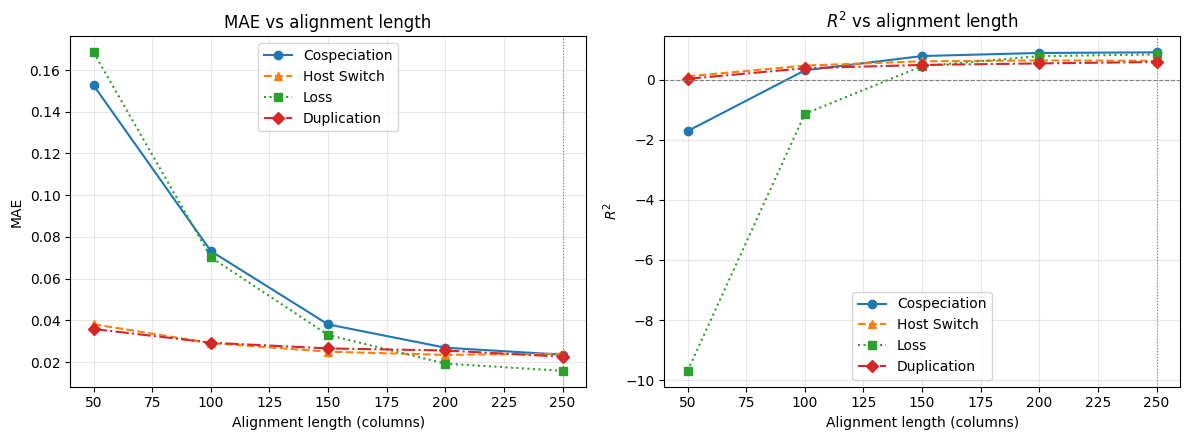

Saved: test_data/error_vs_seqlen.png


In [ ]:
# -- Plot MAE and R^2 vs alignment length --
import matplotlib.pyplot as plt

DISPLAY = {"Speciation": "Cospeciation", "HGT": "Host Switch",
           "Loss": "Loss", "Duplication": "Duplication"}

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
# marker + line style per event: readable in B&W
for e, mk, ls in zip(EVENT_NAMES, ["o", "^", "s", "D"], ["-", "--", ":", "-."]):
    sub = sweep_df[sweep_df.event == e].sort_values("length")
    ax[0].plot(sub.length, sub.MAE, marker=mk, ls=ls, label=DISPLAY[e])
    ax[1].plot(sub.length, sub.R2,  marker=mk, ls=ls, label=DISPLAY[e])
ax[0].set(xlabel="Alignment length (columns)", ylabel="MAE", title="MAE vs alignment length")
ax[1].set(xlabel="Alignment length (columns)", ylabel="$R^2$", title="$R^2$ vs alignment length")
ax[1].axhline(0, color="gray", lw=0.8, ls="--")
for a in ax:
    a.axvline(250, color="gray", lw=0.8, ls=":")   # trained window
    a.grid(alpha=0.3); a.legend()
plt.tight_layout()
plt.savefig("test_data/error_vs_seqlen.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: test_data/error_vs_seqlen.png")

## Permutation invariance of the MSA row order

A model that estimates cophylogenetic event frequencies should not care about the
*order* in which sequences are listed in the host and parasite MSAs - the same pair of
trees is being described either way. (A bug of exactly this kind was found in evoPF's
outer-product mean.)

The shuffling follows Luc's `shuffle_seqs` datasets in `core.py`
(`UnambiguousMergeOrderDataset` / `MultisizeUnambiguousMergeOrderDataset`): a seeded
`torch.Generator`, `perm = torch.randperm(len(ids))`, MSA rows permuted by `perm` and
the **id list permuted the same way**, with everything downstream rebuilt from the
reordered ids. Adapted here to Fox's paired input: host and parasite MSAs get
independent permutations, the stored distance matrices are permuted consistently
(`D[perm][:, perm]`), and the host/parasite associations are rebuilt **from the leaf
names**, not by index arithmetic - so a wrong permutation shows up as scrambled
associations instead of silently agreeing.

Run over **all** datasets in `DATA_DIR`. Predictions should be identical up to float32
round-off (~1e-7).


In [ ]:
# -- Shuffled dataset (mirrors Luc's `shuffle_seqs` datasets in core.py) --
import glob
import numpy as np
import pandas as pd
from torch.utils.data import Dataset

class ShuffledCophyloDataset(Dataset):
    """Fox .pt datasets, optionally with host/parasite leaf order shuffled.

    Same shuffling contract as core.py's UnambiguousMergeOrderDataset:
    seeded torch.Generator -> randperm over ids -> permute rows AND ids, then
    rebuild everything that references the leaves from the reordered ids.
    """

    def __init__(self, files: list[str], shuffle_seqs: bool = False,
                 seed: int = 123467890) -> None:
        super().__init__()
        self.files = files
        self.shuffle_seqs = shuffle_seqs
        self.rng = torch.Generator()
        self.rng.manual_seed(seed)

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, index):
        s = torch.load(self.files[index], map_location="cpu", weights_only=False)
        host_msas, para_msas = s["host_msas"], s["parasite_msas"]
        host_ids, para_ids = list(host_msas), list(para_msas)
        host_dist, para_dist = s.get("host_dist"), s.get("para_dist")
        hperm = pperm = None

        if self.shuffle_seqs:
            hperm = torch.randperm(len(host_ids), generator=self.rng)
            pperm = torch.randperm(len(para_ids), generator=self.rng)
            host_ids = [host_ids[i] for i in hperm]
            para_ids = [para_ids[i] for i in pperm]
            if host_dist is not None:
                host_dist = host_dist[hperm][:, hperm]
            if para_dist is not None:
                para_dist = para_dist[pperm][:, pperm]

        host_tok = torch.stack([encode_sequence(host_msas[i]) for i in host_ids])
        para_tok = torch.stack([encode_sequence(para_msas[i]) for i in para_ids])
        if host_dist is None:
            host_dist = jukes_cantor_dist(host_tok)
        if para_dist is None:
            para_dist = jukes_cantor_dist(para_tok)

        # associations rebuilt from leaf NAMES against the (possibly reordered) ids
        h_idx = {n: i for i, n in enumerate(host_ids)}
        p_idx = {n: i for i, n in enumerate(para_ids)}
        raw = s["mappings"]
        if raw and isinstance(raw[0][0], str):
            maps = [(h_idx[h], p_idx[p]) for p, h in raw if p in p_idx and h in h_idx]
        elif self.shuffle_seqs:   # index-based mappings: remap through the permutation
            hi = {int(o): i for i, o in enumerate(hperm)}
            pi = {int(o): i for i, o in enumerate(pperm)}
            maps = [(hi[h], pi[p]) for h, p in raw]
        else:
            maps = list(raw)

        return {"file": os.path.basename(self.files[index]),
                "host_tok": host_tok, "para_tok": para_tok,
                "host_dist": host_dist, "para_dist": para_dist,
                "mappings": maps, "host_ids": host_ids, "para_ids": para_ids,
                "labels": s.get("event_frequencies") or s.get("labels")}

def fox_forward(host_tok, para_tok, host_dist, para_dist, maps):
    with torch.no_grad():
        o = model(host_tok.unsqueeze(0).to(device), para_tok.unsqueeze(0).to(device), [maps],
                  host_dist=host_dist.unsqueeze(0).to(device),
                  para_dist=para_dist.unsqueeze(0).to(device))
    return o.squeeze(0).cpu().numpy()

def predict_item(item):
    return fox_forward(item["host_tok"], item["para_tok"],
                       item["host_dist"], item["para_dist"], item["mappings"])

print("ShuffledCophyloDataset ready.")


ShuffledCophyloDataset ready.


In [ ]:
# -- Reference order vs N_PERM shuffled orders, over ALL datasets --
PERM_DATA_DIR = DATA_DIR          # test_data/fox_data
N_PERM        = 5                 # shuffled passes per dataset
SEED          = 123467890         # same default seed as core.py

perm_files = sorted(glob.glob(os.path.join(PERM_DATA_DIR, "*.pt")))   # all datasets

ds_ref = ShuffledCophyloDataset(perm_files, shuffle_seqs=False)
# one shuffled dataset per round; different seed each round -> different permutations
ds_shuf = [ShuffledCophyloDataset(perm_files, shuffle_seqs=True, seed=SEED + k)
           for k in range(N_PERM)]

perm_rows, n_identity = [], 0
for i in range(len(ds_ref)):
    ref = ds_ref[i]
    perm_rows.append({"file": ref["file"], "perm": 0,
                      **{e: v for e, v in zip(EVENT_NAMES, predict_item(ref))}})
    for k, ds in enumerate(ds_shuf, start=1):
        item = ds[i]
        n_identity += int(item["host_ids"] == ref["host_ids"]
                          and item["para_ids"] == ref["para_ids"])
        perm_rows.append({"file": ref["file"], "perm": k,
                          **{e: v for e, v in zip(EVENT_NAMES, predict_item(item))}})

df_perm = pd.DataFrame(perm_rows)
print(f"{len(perm_files)} datasets x {N_PERM} shuffles "
      f"({len(df_perm)} forward passes incl. reference)")
print(f"identity (no-op) shuffles: {n_identity}")
print("example reordering:")
print("  reference host ids:", ds_ref[0]["host_ids"][:8])
print("  shuffled  host ids:", ds_shuf[0][0]["host_ids"][:8])


100 datasets x 5 shuffles (600 forward passes incl. reference)
identity (no-op) shuffles: 0
example reordering:
  reference host ids: ['H28', 'H29', 'H26', 'H16', 'H9', 'H20', 'H21', 'H32']
  shuffled  host ids: ['H35', 'H22', 'H25', 'H33', 'H24', 'H29', 'H26', 'H32']


In [ ]:
# -- Deviation of shuffled predictions from the reference ordering --
perm_base = df_perm[df_perm.perm == 0].set_index("file")[EVENT_NAMES]
df_dev    = df_perm[df_perm.perm > 0].copy()
for e in EVENT_NAMES:
    df_dev[f"dev_{e}"] = df_dev[e].values - perm_base.loc[df_dev.file, e].values

dev_cols = [f"dev_{e}" for e in EVENT_NAMES]
abs_dev  = df_dev[dev_cols].abs()

summary = pd.DataFrame({
    "max |dev|":  abs_dev.max().values,
    "mean |dev|": abs_dev.mean().values,
    "pred range": [perm_base[e].max() - perm_base[e].min() for e in EVENT_NAMES],
}, index=EVENT_NAMES)
summary["max |dev| / range"] = summary["max |dev|"] / summary["pred range"]
print(summary.to_string(float_format=lambda v: f"{v:.3e}"))

worst = abs_dev.values.max()
FLOAT32_EPS = 1e-5          # generous bound on float32 accumulation noise
print(f"\nWorst absolute deviation over all shuffles: {worst:.3e}")
print("VERDICT:", "INVARIANT (within float32 round-off)" if worst < FLOAT32_EPS
      else "NOT INVARIANT - row order changes the prediction")


             max |dev|  mean |dev|  pred range  max |dev| / range
Speciation   1.192e-07   2.199e-08   5.037e-01          2.367e-07
HGT          1.118e-07   1.891e-08   2.020e-01          5.532e-07
Loss         7.451e-08   1.420e-08   2.046e-01          3.642e-07
Duplication  1.043e-07   2.238e-08   1.839e-01          5.672e-07

Worst absolute deviation over all shuffles: 1.192e-07
VERDICT: INVARIANT (within float32 round-off)


/var/folders/4d/nlp0vztn79z4h215lhhyfkh80000gn/T/ipykernel_66125/3652637273.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([abs_dev[f"dev_{e}"].values for e in EVENT_NAMES],


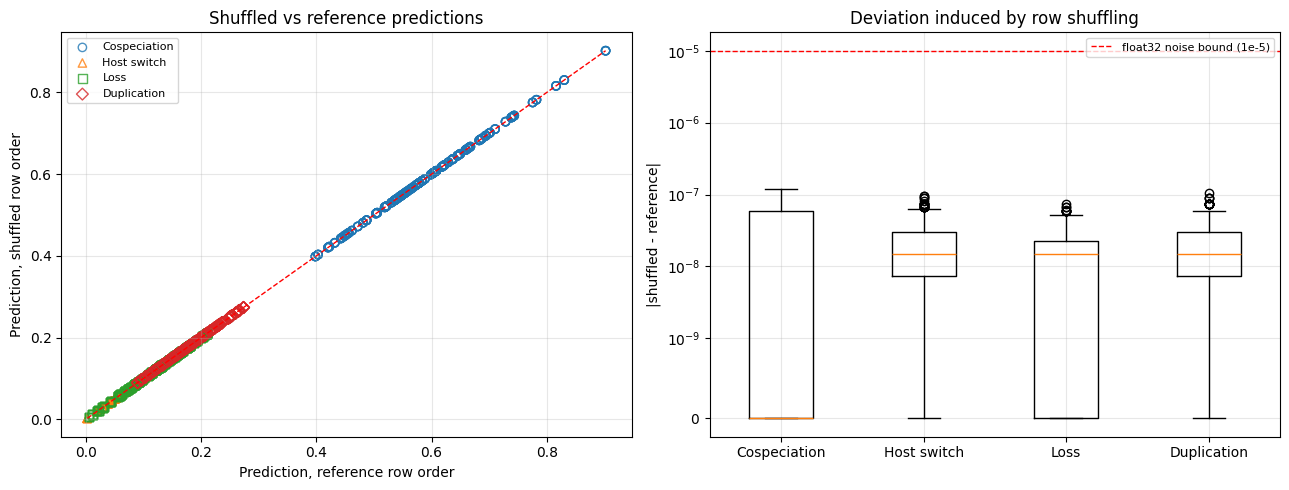

Saved: test_data/permutation_invariance.png


In [ ]:
# -- Plot: reference vs shuffled predictions, and deviation spread --
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
# marker per event: readable in B&W
for e, c, mk in zip(EVENT_NAMES, ["C0", "C1", "C2", "C3"], ["o", "^", "s", "D"]):
    ax.scatter(perm_base.loc[df_dev.file, e].values, df_dev[e].values,
               s=36, alpha=0.8, marker=mk, facecolors="none", edgecolors=c, linewidths=1,
               label=disp(e))
lo = min(perm_base[EVENT_NAMES].values.min(), df_perm[EVENT_NAMES].values.min())
hi = max(perm_base[EVENT_NAMES].values.max(), df_perm[EVENT_NAMES].values.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1)
ax.set_xlabel("Prediction, reference row order")
ax.set_ylabel("Prediction, shuffled row order")
ax.set_title("Shuffled vs reference predictions")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.boxplot([abs_dev[f"dev_{e}"].values for e in EVENT_NAMES],
           labels=[disp(e) for e in EVENT_NAMES], showfliers=True)
ax.set_yscale("symlog", linthresh=1e-9)
ax.axhline(1e-5, color="r", ls="--", lw=1, label="float32 noise bound (1e-5)")
ax.set_ylabel("|shuffled - reference|")
ax.set_title("Deviation induced by row shuffling")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("test_data/permutation_invariance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: test_data/permutation_invariance.png")


In [ ]:
# -- Same check on the real Heliconius dataset (same shuffle contract) --
rng_real = torch.Generator(); rng_real.manual_seed(123467890)

def _shuffled_real(shuffle: bool):
    h_ids, p_ids = list(host_msa), list(para_msa)
    if shuffle:
        h_ids = [h_ids[i] for i in torch.randperm(len(h_ids), generator=rng_real)]
        p_ids = [p_ids[i] for i in torch.randperm(len(p_ids), generator=rng_real)]
    ht = torch.stack([encode_sequence(host_msa[i]) for i in h_ids])
    pt = torch.stack([encode_sequence(para_msa[i]) for i in p_ids])
    hi = {n: i for i, n in enumerate(h_ids)}
    pi = {n: i for i, n in enumerate(p_ids)}
    maps = [(hi[h], pi[p]) for p, h in dist_pairs if p in pi and h in hi]
    return fox_forward(ht, pt, jukes_cantor_dist(ht), jukes_cantor_dist(pt), maps)

rows_real = [{"perm": "reference",
              **{e: v for e, v in zip(EVENT_NAMES, _shuffled_real(False))}}]
for k in range(1, 6):
    rows_real.append({"perm": f"shuffle {k}",
                      **{e: v for e, v in zip(EVENT_NAMES, _shuffled_real(True))}})

df_real_perm = pd.DataFrame(rows_real).set_index("perm")
print(df_real_perm.to_string(float_format=lambda v: f"{v:.6f}"))
worst_real = (df_real_perm - df_real_perm.loc["reference"]).abs().values.max()
print(f"\nWorst absolute deviation (Heliconius): {worst_real:.3e}")


           Speciation      HGT     Loss  Duplication
perm                                                
reference    0.776469 0.040142 0.001667     0.181722
shuffle 1    0.776469 0.040142 0.001667     0.181722
shuffle 2    0.776469 0.040142 0.001667     0.181722
shuffle 3    0.776469 0.040142 0.001667     0.181722
shuffle 4    0.776469 0.040142 0.001667     0.181722
shuffle 5    0.776469 0.040142 0.001667     0.181722

Worst absolute deviation (Heliconius): 1.192e-07


## Robustness to Jukes-Cantor saturation (capped distances)

`jukes_cantor_dist` uses the **nucleotide** (4-state) Jukes-Cantor formula,
$d = -\tfrac{3}{4}\ln(1 - \tfrac{4}{3}p)$, on protein alignments. It diverges at
$p = 0.75$, so $p$ is clamped at 0.74 and every pair above that gets the same
distance ($\approx 3.24$). Protein pairs can differ at up to $\sim 95\%$ of sites, so
on the simulated test data a large share of pairs sit at that cap.

The protein (20-state) formula is $d = -\tfrac{19}{20}\ln(1 - \tfrac{20}{19}p)$,
valid up to $p = 0.95$. Here we check whether the cap actually costs accuracy:

1. **How much is capped?** Fraction of leaf pairs with $p \ge 0.74$, per dataset.
2. **Does error grow with capping?** Per-dataset MAE vs. capped fraction.
3. **Does the formula matter?** Re-run Fox with the protein formula (never seen in
   training - a zero-shot swap) and, as references for what "the distance input
   matters" looks like, with no distance input and with rows shuffled so they no
   longer match the sequences.

All distances are recomputed from the sequences with the same 250-column window,
so the four conditions differ only in the distance matrix.

In [ ]:
# -- 1-2. Capped fraction per dataset, and error vs capping --
import glob, numpy as np, pandas as pd
from scipy import stats

JC_CAP_P = 0.74
SAT_FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.pt")))

def pdist_p(tok):
    # Pairwise p-distance, same site masking as jukes_cantor_dist (PAD excluded).
    valid = tok != PAD_ID
    vp = valid.unsqueeze(1) & valid.unsqueeze(0)
    n = vp.sum(2).clamp(min=1).float()
    return ((tok.unsqueeze(1) != tok.unsqueeze(0)) & vp).float().sum(2) / n

def upper(m):
    iu = torch.triu_indices(m.shape[0], m.shape[0], 1)
    return m[iu[0], iu[1]]

def jc_protein(tok):
    p = pdist_p(tok).clamp(0.0, 0.94)
    d = -(19 / 20) * torch.log(1.0 - (20 / 19) * p)
    d.fill_diagonal_(0.0)
    return d

def shuffle_rows(d, g):
    i = torch.randperm(d.shape[0], generator=g)
    return d[i][:, i]

sat_samples, sat_rows, all_p = [], [], []
for f in SAT_FILES:
    s = torch.load(f, map_location="cpu", weights_only=False)
    hm, pm = s["host_msas"], s["parasite_msas"]
    ht = torch.stack([encode_sequence(x) for x in hm.values()])
    pt = torch.stack([encode_sequence(x) for x in pm.values()])
    hi = {n: j for j, n in enumerate(hm)}; pi = {n: j for j, n in enumerate(pm)}
    maps = [(hi[h], pi[p]) for p, h in s["mappings"] if p in pi and h in hi]
    ph, pp = upper(pdist_p(ht)), upper(pdist_p(pt))
    both = torch.cat([ph, pp]); all_p.append(both)
    sat_samples.append((os.path.basename(f), ht, pt, maps,
                        [s["event_frequencies"][e] for e in EVENT_NAMES]))
    sat_rows.append({"file": os.path.basename(f),
                     "capped_host": (ph >= JC_CAP_P).float().mean().item(),
                     "capped_para": (pp >= JC_CAP_P).float().mean().item(),
                     "capped_frac": (both >= JC_CAP_P).float().mean().item(),
                     "n_pairs": both.numel()})
df_sat = pd.DataFrame(sat_rows)
all_p = torch.cat(all_p)

print(f"{len(df_sat)} datasets, {all_p.numel():,} leaf pairs (host + parasite)")
print(f"pairs with p >= {JC_CAP_P}: {(all_p >= JC_CAP_P).sum().item():,} "
      f"({100 * (all_p >= JC_CAP_P).float().mean():.1f}%),  max p = {all_p.max():.3f}")
print(f"datasets with at least one capped pair: {(df_sat.capped_frac > 0).sum()}/{len(df_sat)}")
print("\np-distance distribution:")
edges = [0, .5, .65, JC_CAP_P, .8, .9, 1.0001]
for lo, hi in zip(edges[:-1], edges[1:]):
    share = ((all_p >= lo) & (all_p < hi)).float().mean().item()
    print(f"  [{lo:.2f}, {min(hi, 1):.2f}){'  <- capped' if lo >= JC_CAP_P else '':12s} {100 * share:5.1f}%")

100 datasets, 800,760 leaf pairs (host + parasite)
pairs with p >= 0.74: 368,385 (46.0%),  max p = 0.956
datasets with at least one capped pair: 96/100

p-distance distribution:
  [0.00, 0.50)               3.6%
  [0.50, 0.65)              27.1%
  [0.65, 0.74)              23.3%
  [0.74, 0.80)  <- capped   20.0%
  [0.80, 0.90)  <- capped   24.7%
  [0.90, 1.00)  <- capped    1.3%


In [ ]:
# -- 3. Re-run Fox with different distance inputs (same sequences, same window) --
SAT_CONDITIONS = {
    "JC 4-state (as trained)": lambda t, g: jukes_cantor_dist(t),
    "JC 20-state (protein)":   lambda t, g: jc_protein(t),
    "no distance input":       lambda t, g: None,
    "rows shuffled":           lambda t, g: shuffle_rows(jukes_cantor_dist(t), g),
}

g_sat = torch.Generator(); g_sat.manual_seed(0)
sat_pred = {c: [] for c in SAT_CONDITIONS}
sat_true = []
with torch.no_grad():
    for i, (name, ht, pt, maps, true) in enumerate(sat_samples):
        sat_true.append(true)
        for c, fn in SAT_CONDITIONS.items():
            hd, pd_ = fn(ht, g_sat), fn(pt, g_sat)
            out = model(ht.unsqueeze(0).to(device), pt.unsqueeze(0).to(device), [maps],
                        host_dist=None if hd is None else hd.unsqueeze(0).to(device),
                        para_dist=None if pd_ is None else pd_.unsqueeze(0).to(device))
            sat_pred[c].append(out.squeeze(0).cpu().tolist())
        if (i + 1) % 20 == 0:
            print(f"  {i+1}/{len(sat_samples)} done")

T_sat = np.array(sat_true)
P_sat = {c: np.array(v) for c, v in sat_pred.items()}
P_ref = P_sat["JC 4-state (as trained)"]
for c, P in P_sat.items():
    df_sat[f"mae_{c}"] = np.abs(P - T_sat).mean(1)

rows = []
for c, P in P_sat.items():
    mae = np.abs(P - T_sat).mean(0)
    r2 = 1 - ((T_sat - P) ** 2).sum(0) / ((T_sat - T_sat.mean(0)) ** 2).sum(0)
    rows.append({"condition": c, "MAE": mae.mean(),
                 **{f"MAE {disp(e)}": mae[j] for j, e in enumerate(EVENT_NAMES)},
                 "mean R²": r2.mean(),
                 "mean |Δpred| vs trained": np.abs(P - P_ref).mean(),
                 "max |Δpred| vs trained": np.abs(P - P_ref).max()})
rows.append({"condition": "baseline: predict the mean",
             "MAE": np.abs(T_sat - T_sat.mean(0)).mean(),
             **{f"MAE {disp(e)}": v for e, v in zip(EVENT_NAMES, np.abs(T_sat - T_sat.mean(0)).mean(0))}})
sat_summary = pd.DataFrame(rows).set_index("condition")
print(sat_summary.to_string(float_format=lambda v: f"{v:.4f}", na_rep="-"))

  20/100 done


  40/100 done


  60/100 done


  80/100 done


  100/100 done
                              MAE  MAE Cospeciation  MAE Host switch  MAE Loss  MAE Duplication  mean R²  mean |Δpred| vs trained  max |Δpred| vs trained
condition                                                                                                                                                
JC 4-state (as trained)    0.0215            0.0235           0.0240    0.0158           0.0226   0.7410                   0.0000                  0.0000
JC 20-state (protein)      0.0235            0.0272           0.0246    0.0186           0.0237   0.7216                   0.0102                  0.0497
no distance input          0.1210            0.1848           0.1013    0.1023           0.0958  -4.8346                   0.1188                  0.5789
rows shuffled              0.1232            0.1908           0.0608    0.1869           0.0543  -5.2484                   0.1215                  0.4807
baseline: predict the mean 0.0503            0.0807          

In [ ]:
# -- Error by capped fraction: trained formula vs protein formula --
C4, C20 = "JC 4-state (as trained)", "JC 20-state (protein)"
bins = [0, .1, .3, .5, .7, 1.0001]
labels = ["0-10%", "10-30%", "30-50%", "50-70%", "70-100%"]
df_sat["capped_bin"] = pd.cut(df_sat.capped_frac, bins, labels=labels, right=False)
by_bin = df_sat.groupby("capped_bin", observed=False).agg(
    n=("file", "size"),
    **{f"MAE {C4}": (f"mae_{C4}", "mean"), f"MAE {C20}": (f"mae_{C20}", "mean")})
print("Mean per-dataset MAE by share of capped leaf pairs:")
print(by_bin.to_string(float_format=lambda v: f"{v:.4f}"))

rho, pval = stats.spearmanr(df_sat.capped_frac, df_sat[f"mae_{C4}"])
print(f"\nSpearman(capped fraction, MAE) = {rho:.3f}  (p = {pval:.2f}, n = {len(df_sat)})")

heavy = df_sat.capped_frac >= 0.5
for c in (C4, C20):
    print(f"{c:26s} MAE  <50% capped: {df_sat.loc[~heavy, f'mae_{c}'].mean():.4f} (n={(~heavy).sum()})"
          f"   >=50% capped: {df_sat.loc[heavy, f'mae_{c}'].mean():.4f} (n={heavy.sum()})")

Mean per-dataset MAE by share of capped leaf pairs:
             n  MAE JC 4-state (as trained)  MAE JC 20-state (protein)
capped_bin                                                            
0-10%       26                       0.0181                     0.0212
10-30%      23                       0.0210                     0.0238
30-50%      12                       0.0236                     0.0268
50-70%      22                       0.0261                     0.0258
70-100%     17                       0.0199                     0.0214

Spearman(capped fraction, MAE) = 0.097  (p = 0.33, n = 100)
JC 4-state (as trained)    MAE  <50% capped: 0.0202 (n=61)   >=50% capped: 0.0234 (n=39)
JC 20-state (protein)      MAE  <50% capped: 0.0233 (n=61)   >=50% capped: 0.0239 (n=39)


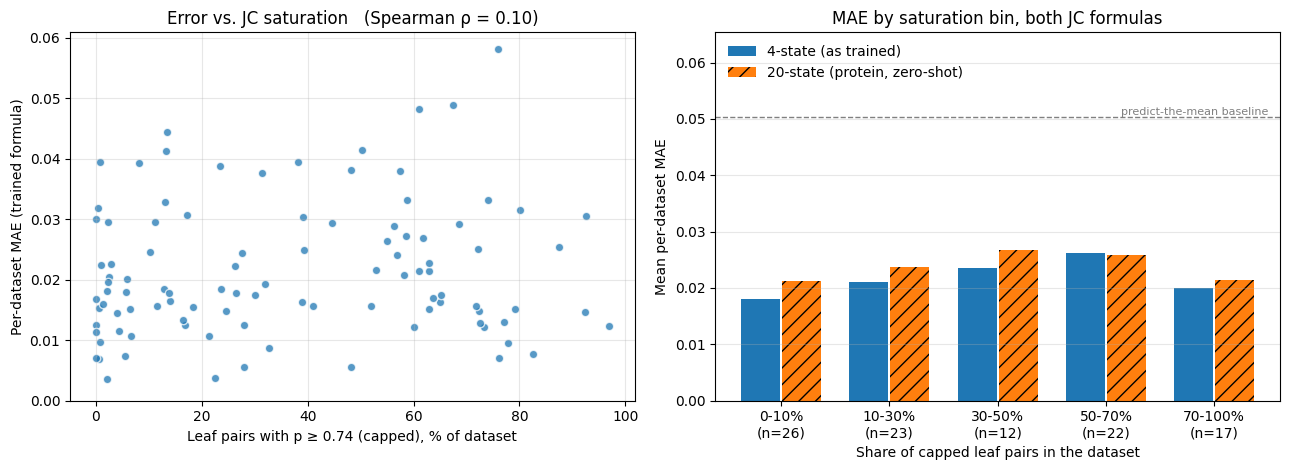

In [ ]:
# -- Plot: error vs capped fraction, and per-bin MAE for both formulas --
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
ax.scatter(100 * df_sat.capped_frac, df_sat[f"mae_{C4}"], s=36, alpha=0.75,
           color="C0", edgecolor="white", linewidth=1)
ax.set_xlabel(f"Leaf pairs with p ≥ {JC_CAP_P} (capped), % of dataset")
ax.set_ylabel("Per-dataset MAE (trained formula)")
ax.set_title(f"Error vs. JC saturation   (Spearman ρ = {rho:.2f})")
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

ax = axes[1]
x = np.arange(len(labels)); w = 0.38
for off, c, col, hatch, lab in [(-w / 2, C4, "C0", None, "4-state (as trained)"),
                                ( w / 2, C20, "C1", "//", "20-state (protein, zero-shot)")]:
    # stripes: readable in B&W
    ax.bar(x + off, by_bin[f"MAE {c}"].values, w - 0.02, color=col, label=lab,
           hatch=hatch, edgecolor="black", linewidth=0)
ax.axhline(sat_summary.loc["baseline: predict the mean", "MAE"], color="gray", ls="--", lw=1)
ax.text(len(labels) - 0.5, sat_summary.loc["baseline: predict the mean", "MAE"],
        "predict-the-mean baseline", ha="right", va="bottom", fontsize=8, color="gray")
ax.set_xticks(x, [f"{l}\n(n={n})" for l, n in zip(labels, by_bin["n"].values)])
ax.set_ylim(0, 1.3 * sat_summary.loc["baseline: predict the mean", "MAE"])
ax.set_xlabel("Share of capped leaf pairs in the dataset")
ax.set_ylabel("Mean per-dataset MAE")
ax.set_title("MAE by saturation bin, both JC formulas")
ax.legend(frameon=False, loc="upper left")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Reading the results.** Removing the distance input, or shuffling it so it no longer
matches the sequences, makes Fox much worse (worse than predicting the mean), so the
model depends heavily on the distance matrix. Even so, error does not grow with the
share of capped pairs, and swapping in the protein formula zero-shot changes the
predictions only slightly. The model uses the relative structure of the distances,
which both formulas share below the cap, and gets whatever the cap removes from the
MSA itself. So the saturated 4-state formula costs no measurable accuracy on these
data, and moving to the protein formula (or raw $p$) in a future retrain is not
expected to change results much.

Caveat: this uses the simulated test set in `DATA_DIR`. Real alignments that are more
divergent than the simulations would have more capped pairs.